# **Building and Training a Basic Neural Network using TensorFlow/Keras**

**Course:** Applied Machine Learning

**Assessment:** Assignment 2

**Submission:** 31 May 2026

**Data Source:** [MNIST Dataset](https://web.archive.org/web/20200430193701/http://yann.lecun.com/exdb/mnist/)

# Assignment Brief

This assignment is an introduction to **deep learning**. The objectives are:
  * to understand deep learning workflows,
  * to implement and train neural networks,
  * and, to evaluate models, interpret results and communicate findings.

For this assignment, use any of the working environments such as *Python*, *Jupyter Notebook* or *Google Collab*. You may use any library of your choice such as *NumPy*, *Matplotlib*, *TensorFlow*, or *PyTorch*.


## Questions

### Question 1.

Use the MNIST beginner dataset to load and visualize samples, normalize input
data and to split into training/testing sets.                

Describe the data; specify any decision and assumptions that you made, present
a sample of visualizations and explain your observations made.  


### Question 2.

Implement a simple feedforward neural network with over 700 features, and at
one or two hidden layers and an output layer of 10 classes.            

The work should cover the following concepts; activation function (ReLU or
Softmax), loss function and optimization (SGD or Adam). Provide the code and an explanation of the architecture choices that made


### Question 3.

Train the model and track the loss curve and accuracy.             

Plots the training performance vs validation performance and provide an analysis about the performances such as overfitting and describing the performance changes over epochs.  


### Question 4.

Improve the model using at two of the following:              
  -  Add more layers  
  - Change activation functions  
  - Tune learning rate  

In a table, compare of models before and after the improvements, and justify the changes made to the model.  


### Question 5.

Implement a simple Convolutional Neural Network (CNN) for the same dataset:
  - Conv layer(s)  
  - Pooling  
  - Fully connected layer  

Provide the code and explain why CNN works better for images.  


### Question 6.

Visualize the following:
  - Misclassified examples  
  - Confusion matrix  

In the interpretation, highlight which digits are hardest to classify?

Why?       


# Environment Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re, math, os
from decimal import Decimal
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier

from pandas.api.types import is_object_dtype
from sklearn.metrics import classification_report, confusion_matrix

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)



Mounted at /content/drive


# Load the MNIST dataset



# Preprocess the dataset



# Build and train a small neural network from scratch

# Data Overview

Next, I wanted to perform a general overview of my data so I can get familiar with it. This step is also replicated from the Zindi.Africa starter notebook but it is an essential step and I will include my findings from this step.

## Data Shape and Information

In [ ]:
# ========================================
# DATASET OVERVIEW
# ========================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nTrain Dataset Shape: {train_df.shape}")
print(f"Test Dataset Shape: {test_df.shape}")
print(f"\nNumber of Features in Train: {train_df.shape[1]}")
print(f"Number of Features in Test: {test_df.shape[1]}")

# Check for target variable
FHI = 'Target'
if FHI in train_df.columns and FHI not in test_df.columns:
    print(f"\n✓ Target variable 'FHI' found in train set")
    print(f"✓ Target variable correctly absent from test set")
else:
    print("\n⚠ Check target variable presence!")

DATASET OVERVIEW

Train Dataset Shape: (9618, 39)
Test Dataset Shape: (2405, 38)

Number of Features in Train: 39
Number of Features in Test: 38

✓ Target variable 'FHI' found in train set
✓ Target variable correctly absent from test set


By producing the dataframe ````shape```` for the training and test datasets, I was able to confirm that the training data set has 9,618 records or rows, and 39 columns. I ran this experiment more than once, initially losing my data and needing to start again. The first time around, I was a bit nervous running these commands, so I also used a spreadsheet software to confirm the overview results that I was seeing here. I ran the ````COUNTA```` function to count the number of rows in both data sets. The record count was confirmed for both datasets. In addition, the column count was confirmed.

By running the ````head```` command using the ````display```` command, I find that I am able to do the same thing that I did with the spreadsheet. I needed to preview the column labels and just look at the data. The ````display```` command prints the results of ````head```` to the screen as a design formatted table. Head prints table headers and the first five rows as per the CSV data file. The results can be seen below. In previewing the data, I was able to determine that the target **financial health index** (FHI) was actually called *Target* and not *FHI* as the starter notebook had suggested. So I changed it accordingly in the above short script for *dataset overview*. The script had not been working correctly in the check for target variable.

In running the same ````head```` and ````display```` commands on the test data set, I was able to determine that the target variable is infact missing in that data set. Returning to our ````shape```` results above, we were made aware by the test data set having a row count of 38. This is infact as we intend for this exercise. Futhermore, I simply noted that the test data has a record count of 2,405. I had also tested this in previous iterations of this exercise in a spreadsheet program/application. The spreadsheet with the formulas has not been included alongside this particular iteration. It was not necessary.

Directly below this, I used the ````display```` function to reveal the contents of the variable definitions data frame. Using this information, I was able to confirm that I expected to have 39 variables for these datasets, and what those 39 were to be, as well as the definition for each of the 39 variables. This helped me to familiarize myself with the data set. Note again, I said 39 variables but the test data set intentionally has 38 variables.

In [ ]:
display(variable_definitions)

,VARIABLE_NAME,VARIABLE_DESCRIPTION
0,ID,Unique identifier for each business record
1,country,Country where the business is located (Eswatin...
2,owner_age,Age of the business owner in years
3,attitude_stable_business_environment,Owner attitude: Country will have a stable bus...
4,attitude_worried_shutdown,Owner attitude: Worried that the business will...
5,compliance_income_tax,Business complies with or acts in accordance w...
6,perception_insurance_doesnt_cover_losses,Owner perception: Insurance does not cover the...
7,perception_cannot_afford_insurance,Owner perception: Cannot afford insurance paym...
8,personal_income,Total monthly personal income of the owner bef...
9,business_expenses,Approximate monthly or annual expenses of the ...


In [ ]:
display(train_df.head())

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,...,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,...,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,...,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,...,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,...,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low


In [ ]:
display(test_df.head())

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender
0,ID_5EGLKX,zimbabwe,50.0,No,No,No,No,Yes,100.0,3600.0,...,NaN,NaN,NaN,No,8.0,Never had,Never had,NaN,NaN,NaN
1,ID_4AI7RE,lesotho,36.0,Yes,Yes,No,Yes,Yes,900.0,400.0,...,NaN,NaN,NaN,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now
2,ID_V9OB3M,lesotho,25.0,Don’t know or N/A,No,No,Don't know,Don't know,5250.0,350.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,No,Never had,Used to have but don't have now
3,ID_6OI9DI,malawi,25.0,Don’t know or N/A,Yes,No,No,Yes,485000.0,10000.0,...,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,Have now,Never had
4,ID_H2TN8B,lesotho,47.0,No,Yes,No,Don't know,Don't know,97.0,500.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now


In [ ]:
display(ss_df.head())

,ID,Target
0,ID_5EGLKX,Low
1,ID_4AI7RE,Low
2,ID_V9OB3M,Low
3,ID_6OI9DI,Low
4,ID_H2TN8B,Low


The data displayed above is the contents of the sample submission data frame. It was good to familiarize myself with the format of the expected data output, and submission file for the Zindi.Africa competition. This [Data Shape and Information section](#scrollTo=Data_Shape_and_Information) is similar to the "*Take a Quick Look at the Data Structure*" section outlined by Geron in the example project, in the book "*Hands on Machine Learning with Scikit Learn, Keras, & TensorFlow*".

Below, I used the ````info```` command to get more information about my training and test datasets. I was able to confirm the data types in the column fields, and the non-null counts. Thus, any count that is below the row count is assumed to be the number of records that have non-null values, thus the difference between this number shown per column by info and the row count derived above is the number of records with null values for that column. Info tells us that the data is largely divided between data objects and floating point integer values. Upon closer inspection it is clear that the objects are mainly where text input was submitted, even if the value can be easily coded as a binary value in our minds when we look at it. For example **attitude worried shutdown** column takes *yes* or *no*. This has the same data type coding as the **country** column, which is a variable length text field, and infact we already that the data was collected from among four countries. I did not find a significance for the memory usage information

In [ ]:
print("\n--- TRAIN SET INFO ---")
print(train_df.info())

print("\n--- TEST SET INFO ---")
print(test_df.info())


--- TRAIN SET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9618 entries, 0 to 9617
Data columns (total 39 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   ID                                                                9618 non-null   object 
 1   country                                                           9618 non-null   object 
 2   owner_age                                                         9618 non-null   float64
 3   attitude_stable_business_environment                              9616 non-null   object 
 4   attitude_worried_shutdown                                         9616 non-null   object 
 5   compliance_income_tax                                             9614 non-null   object 
 6   perception_insurance_doesnt_cover_losses                          9613 non-null   object 
 7   perceptio

# Data Quality Analysis

## Target Variable Analysis


TARGET VARIABLE ANALYSIS

Target Distribution:
Target
High       470
Low       6280
Medium    2868
Name: count, dtype: int64

Target Proportions:
Target
High      0.048867
Low       0.652942
Medium    0.298191
Name: proportion, dtype: float64


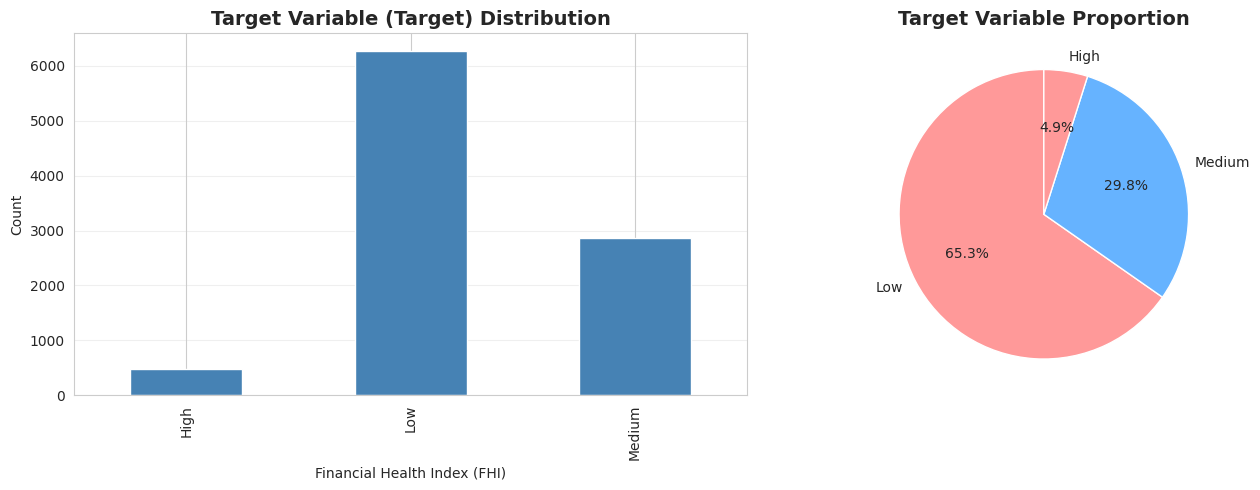


⚠ Class imbalance detected! Ratio: 13.36:1


In [ ]:
print("\n" + "=" * 60)
print("TARGET VARIABLE ANALYSIS")
print("=" * 60)

if 'Target' in train_df.columns:
    print("\nTarget Distribution:")
    print(train_df['Target'].value_counts().sort_index())
    print(f"\nTarget Proportions:")
    print(train_df['Target'].value_counts(normalize=True).sort_index())

    # Visualize target distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Count plot
    train_df['Target'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Target Variable (Target) Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Financial Health Index (FHI)')
    axes[0].set_ylabel('Count')
    axes[0].grid(axis='y', alpha=0.3)

    # Pie chart
    target_counts = train_df['Target'].value_counts()
    axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
                startangle=90, colors=['#ff9999', '#66b3ff'])
    axes[1].set_title('Target Variable Proportion', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Check for class imbalance
    class_ratio = train_df['Target'].value_counts().max() / train_df['Target'].value_counts().min()
    if class_ratio > 1.5:
        print(f"\n⚠ Class imbalance detected! Ratio: {class_ratio:.2f}:1")
    else:
        print(f"\n✓ Classes are relatively balanced. Ratio: {class_ratio:.2f}:1")

    pass

Above, and as stated in the started notebook, I have decided to look more into the characteristics of the target variable, which is only found in the training dataset. Here, I have used ````value_counts```` function on the training dataset's **Target** column. This result/work has been sorted by the target column's values in ascending order. That is, we have been shown that the Target variable is categorical, taking on three distinct text values i.e. High, Low, and Medium. If you recall from the ````info```` command, this column had no null values and all records have a value for it. Thus, if we sum up the three values for each category (High=470, Low=6280, Medium=2868), we should derive the count of the complete training dataset (9618) which we do.

Furthermore, the second command does the same thing as the first command to find out the categories of the target FHI variable and count how many records fall into each category, then it normalizes the data so that we get preview categorical data as a fraction of a whole. Here we can see, confirming with the first ````value_counts```` result that, given this data, a majority of the people had a low FHI value, followed by the medium category, and finally a low number or proportion of the people interviewed had a high FHI index. So we can expect that most people have a very poor (LOW) Financial Health Index (FHI) in the populations under study, based on the results of this sample.

For people whom do not easily understand numbers, a bar chart and a pie chart of this information was produced and they both confirm the same thing, visually.

There is a final section of code that 'checks for class imbalance'. This is not an intuitive concept. This check is performed for the class with the highest value (````max````) and the class with the lowest value (````min````). Supposedly, a desired ratio is 1.5:1 between these two categories of the target variable. However for our dataset, it was 13.36:1 and thus an alert was raised. The starter notebook explains that an imbalanced categorical ratio prompts us to use non-standard data modelling techniques for our data, as well as possibly needing us to:

* perform class weighting,
* apply resampling,
* or even use of specialized evaluation metrics.

## Missing Data Analysis

In [ ]:
def analyze_missing(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing_Count': missing.values,
        'Percentage': missing_pct.values
    }).query('Missing_Count > 0').sort_values('Percentage', ascending=False)

    print(f"\n{name} - Columns with Missing Values:")
    if len(missing_df) > 0:
        print(missing_df.to_string(index=False))
        print()

        # Visualize top missing columns
        if len(missing_df) > 0:
            top_missing = missing_df.head(15)
            plt.figure(figsize=(12, 6))
            plt.barh(top_missing['Column'], top_missing['Percentage'], color='coral')
            plt.xlabel('Missing Percentage (%)')
            plt.title(f'{name} - Top Columns with Missing Values', fontsize=14, fontweight='bold')
            plt.gca().invert_yaxis()
            plt.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.show()
    else:
        print("No missing values found!")

    return missing_df

Above, we have defined a function that will handle analyzing missing data for us. This function could be turned into a script that automates this process. What it is doing is, given some data frame "**train**", it iterates through the entire table or data set, checking the data entry for each record by feature. If no data is found in any cell, it enters the boolean *True* to indicate that the column is/was null, then enters *False* otherwise. This is done through the ````isnull()```` numpy function. Thus, it produces a kind of truth table for the entire dataset. Through the ````sum()```` function it then counts the number of *True* values per feature, producing a feature table, similar to the definitions data frame, which contains counts for the number of records that had null values for that feature. This data is stored into a new data frame ````missing````.

The function them computes the percentages of null values for each feature in the same table, which is also saved to a new data frame ````missing_pct````. All of this data is used to create the new data frame ````missing_df```` which contains the feature names, the count for missing values, and the proportion of the entire data that the feature is null (as a percentage). Furthermore, the dataframe is then queried for all features that had some kind of a missing value, sorted in descending order by the percentage column. Essentially, we drop all features that had no null values, leaving us with a data that we can inspect more closely (or an empty data frame object if no nulls were discovered in the complete data set).

If a data frame was infact created, we then plot column features that had the most missing values in a bar (horizontal) graph (we use the ````head```` function, I counted 15 features plotted on the graph but there are more according to the table). This function/script was run for the training data set and the testing data set, and the results are shown below.






MISSING VALUES ANALYSIS: TRAINING DATA SET

TRAIN SET - Columns with Missing Values:
                                                          Column  Missing_Count  Percentage
                                            uses_informal_lender           4489   46.672905
                                     uses_friends_family_savings           4488   46.662508
                                      motivation_make_more_money           4291   44.614265
                                               funeral_insurance           4188   43.543356
                                               medical_insurance           4188   43.543356
                                             business_age_months           4111   42.742774
                                         future_risk_theft_stock           4100   42.628405
                                                  has_debit_card           4003   41.619879
                                            has_internet_banking           4003   41.6

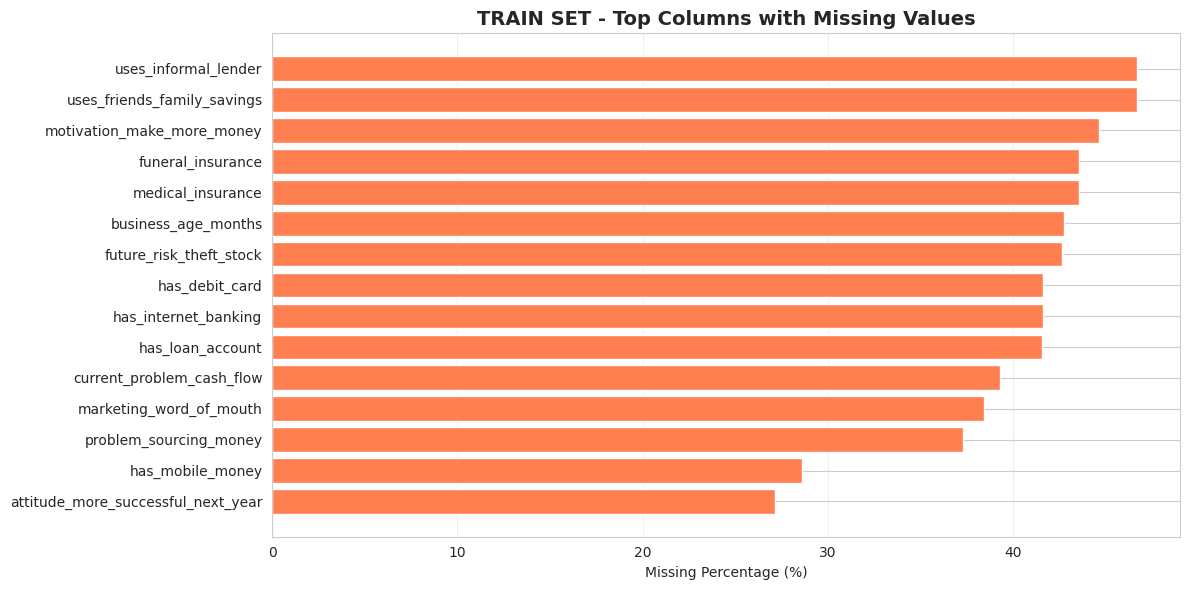

In [ ]:
print("\n" + "=" * 60)
print("MISSING VALUES ANALYSIS: TRAINING DATA SET")
print("=" * 60)
train_missing = analyze_missing(train_df, "TRAIN SET")


MISSING VALUES ANALYSIS: TEST DATA SET

TEST SET - Columns with Missing Values:
                                                          Column  Missing_Count  Percentage
                                     uses_friends_family_savings           1131   47.027027
                                            uses_informal_lender           1131   47.027027
                                      motivation_make_more_money           1084   45.072765
                                               funeral_insurance           1042   43.326403
                                               medical_insurance           1042   43.326403
                                             business_age_months           1033   42.952183
                                         future_risk_theft_stock           1017   42.286902
                                                  has_debit_card            992   41.247401
                                                has_loan_account            992   41.247401

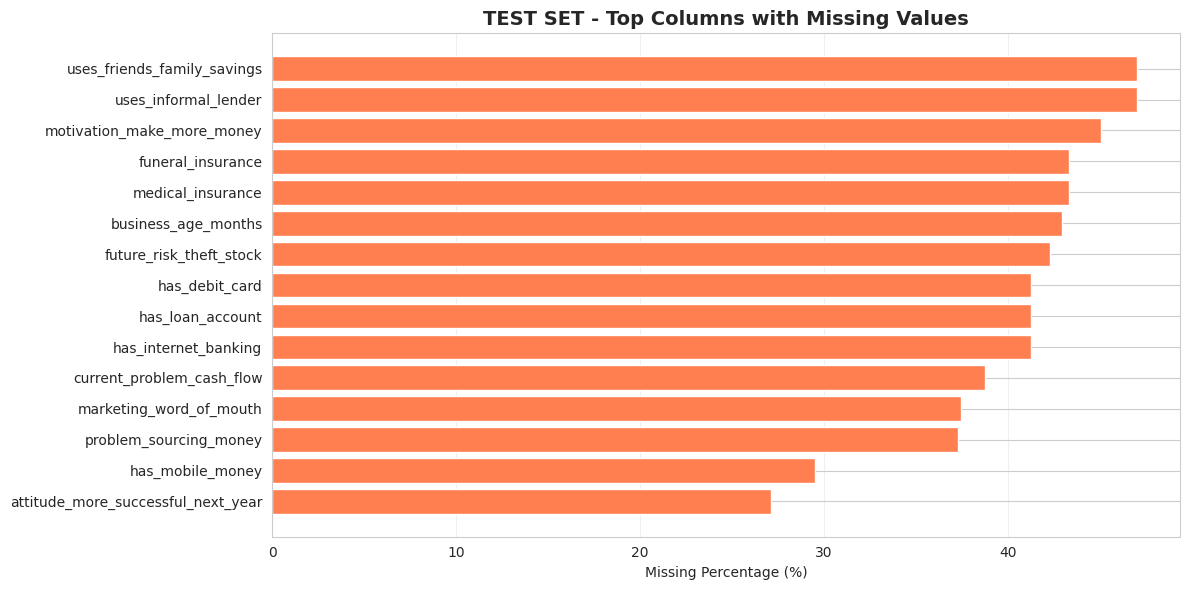

In [ ]:
print("\n" + "=" * 60)
print("MISSING VALUES ANALYSIS: TEST DATA SET")
print("=" * 60)
test_missing = analyze_missing(test_df, "TEST SET")

The two graphs above look quite very similar, which is eerie. Upon closer inspection though, the phenomenon of missing values is not simply duplicated across the two data sets. The top two features with the highest number of missing values in both data sets are *uses friends family savings* and *uses informal lender*. However, the latter is at the very top in the test data set, and second in the training data set. And the former of the two is in second place in the test data set but at the very top in the training data set.

The bottom two features in the test data set and the training data set graphs for variables containing null values are exactly the same; *has mobile money* and *attitude more successful next year*. Infact, closer inspection shows that some of the other features are also largely similar, in ordering, but not always the same across the two graphs.

According to the starter notebook, understanding missingness helps to guide us in:
* Feature selection and removal
* Choosing an imputation strategy (mean, median, mode, model-based, etc.)
* And, detecting systematic data collection issues  

Thus in the above steps we have somehow revealed the quality of the data. Confirmation, is a subjective thing as experienced analysts will have more insight into what all the numbers and charts mean, while inexperienced ones will only have the objective base statistics to report on/about. I am for example aware that some people who submit such forms think outside of the box, and will not repeat themselves, thus if you are very familiar with the questions asked or feature set, you can derive data from the other fields. For example, must they use both *informal lender* and *family and friends' savings*. Some might have given an answer for one, and assumed it was not necessary to select the other, unless the survey given out was specific to say that multiple options could be chosen. According to the earlier feature descriptions, both are considered to be *informal financing* options, but nothing says that they are exclusive in the data that we are given.

Another interesting field is the *motivation make more money* feature. Looking at the sample ````head```` preview data that was provided in earlier sections, it seems that the answers were yes, and no. Then, there were those that opted not to answer, which is the null field entry. Rather than drop the feature, we could find ways to predict if the user likely meant no in skipping this or not providing relevant data as the about 45% of our training dataset that had nulls for this feature is a bit much to discard.

## Numerical Feature Analysis

In [ ]:
# Identify numerical columns
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Target' in numerical_cols:
    numerical_cols.remove('Target')
    pass

print(f"\nNumerical Features ({len(numerical_cols)}):")
display(numerical_cols)


Numerical Features (6):


['owner_age',
 'personal_income',
 'business_expenses',
 'business_turnover',
 'business_age_years',
 'business_age_months']

In the code above, from the training data set, we have selected all the columns that contain data formatted as ````int64```` or ````float64````. Then, we selected their labels using the ````columns```` function and converted them into a list. We have previously looked at the FHI variable in the training data, thus we will exclude it from this analysis. I have once again preferred the ````display```` over ````print```` for the neatness of the result produced!

Below, I have produced the statistical summary of the numerical feature set. Once again, ````display```` produced a single table, while print truncates the table for features on the far right that could not fit on screen. Comparing both results, display has done a better job. The data haas been limited to 9 significant figures for cleanliness.

In [ ]:

# Statistical summary
print("\nStatistical Summary:")
# pd.set_option('display.float_format', '{:.9g}'.format)
display(train_df[numerical_cols].describe().style.format("{:.9g}"))


Statistical Summary:


,owner_age,personal_income,business_expenses,business_turnover,business_age_years,business_age_months
count,9618,9509,9389,9402,9366,5507
mean,41.7053441,262734.474,458383.845,1348209.72,7.03053598,3.6362811
std,13.31401,2566268.07,6184746.45,8804741.07,7.65034933,3.38648816
min,18,0,0,0,0,0
25%,32,300,700,1500,2,0
50%,40,2000,3000,6000,4,3
75%,50,25000,25000,50000,10,6
max,103,150000000,500000000,420000000,60,11


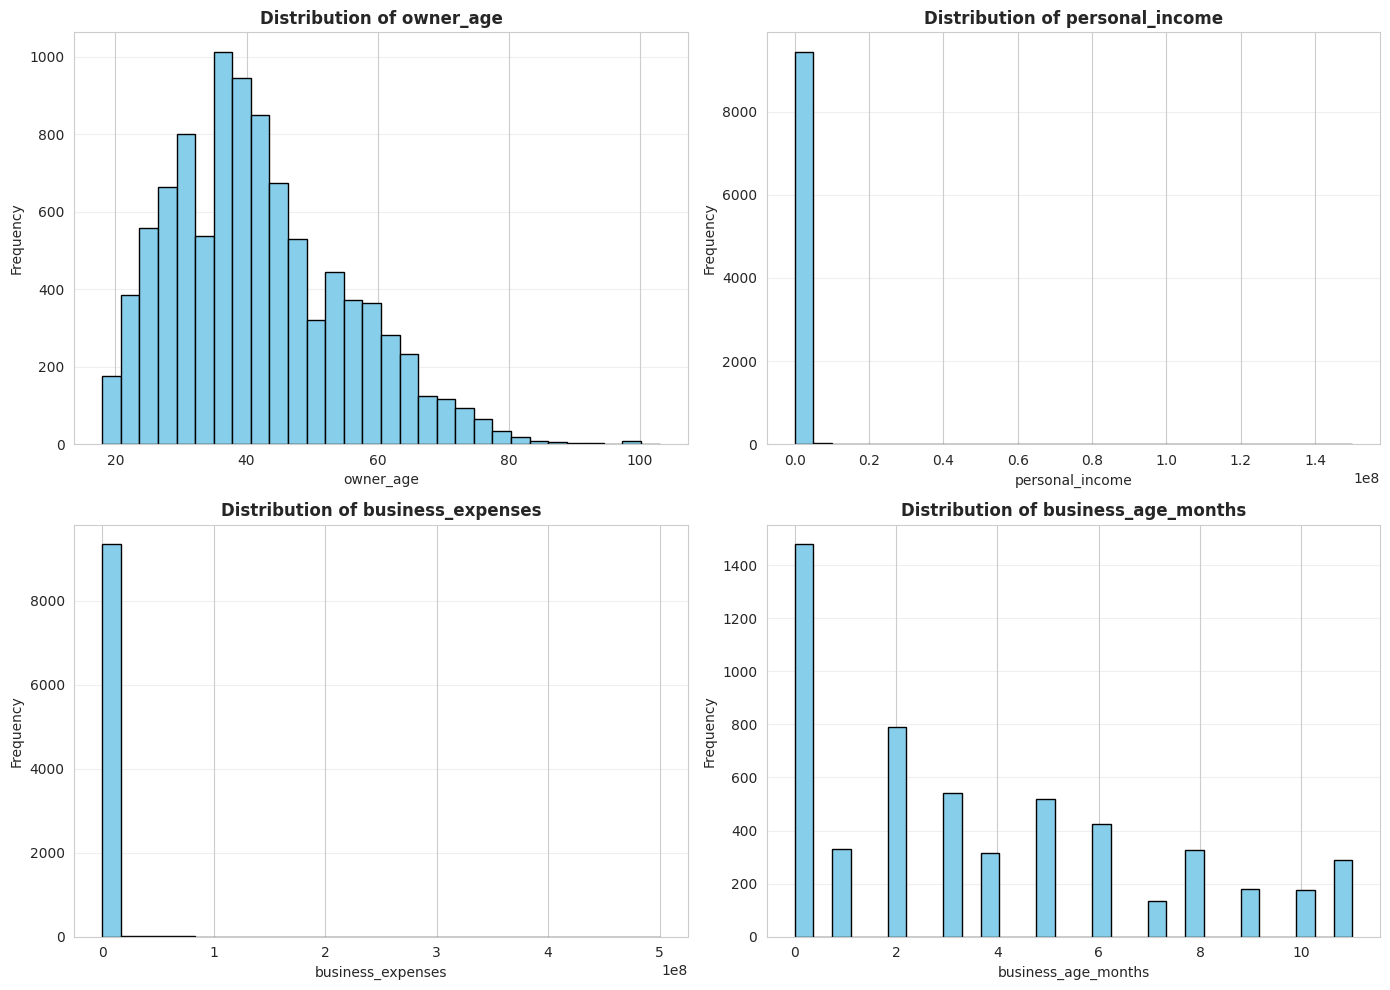

In [ ]:
# Visualize distributions of key numerical features
key_numerical = ['owner_age', 'personal_income', 'business_expenses', 'business_age_months']
available_numerical = [col for col in key_numerical if col in train_df.columns]

if available_numerical:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for idx, col in enumerate(available_numerical[:4]):
        train_df[col].hist(bins=30, ax=axes[idx], color='skyblue', edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

If you recall, exactly 6 features were identified as being numerical in nature at the beginning of this numerical analysis section. Then, we were guided by the starter notebook to work with exactly 4 features, for which we have produced the above frequency or distribution tables. These show us how many records in the training data set occur in any given value.


From the frequency bar graphs, we can see that age has a poison distribution shape, rather than a normal bell shape curve. *Peronsal income* seems to be largely concentrated at the lower end of the income scale, where the statistics print out showed us a minimum of 0, a maximum of 150m, and an average of 262,734 in the given currency at a monthly frequency. These four variables were deemed to be key variables for this dataset. The distribution of the business expenses demonstrates a similar graphical pattern as the personal income frequency graph, generally speaking. One might not know if the long bar at the beginning were remove, if the pattern for the rest of the bars in both graphs will persist. We might find that they have varied patterns, and that the one long frequency bar at the beginned suppressed those interesting patterns from view.

According to the Zindi.Africa starter notebook, comprehending key feature distributions will enable us to perform:
* Feature scaling and normalization  
* Outlier treatment  
* Choose appropriate modeling techniques  


In [ ]:
corr_matrix = train_df[numerical_cols].corr(numeric_only=True)
display(corr_matrix)

,owner_age,personal_income,business_expenses,business_turnover,business_age_years,business_age_months
owner_age,1.000000,-0.014688,-0.004409,-0.013448,0.422112,0.032437
personal_income,-0.014688,1.000000,0.118292,0.361060,0.022227,0.029809
business_expenses,-0.004409,0.118292,1.000000,0.317377,0.045995,0.025570
business_turnover,-0.013448,0.361060,0.317377,1.000000,0.043415,0.052139
business_age_years,0.422112,0.022227,0.045995,0.043415,1.000000,-0.069206
business_age_months,0.032437,0.029809,0.025570,0.052139,-0.069206,1.000000


Above, I decided to produce an interesting statistical table, which is the correlation table using the ````corr```` function. This was not produced in the starter notebook, however Geron produced it in his example. It is a straight forward table. It tells me the correlation between numerical features in the training data set. This statistic cannot be reproduced for categorical features. Sadly, the FHI target variable is categorical thus none of the produced correlations will be useful towards analysing a relationship of the numerical features with the target variable. Reading the complete table is interesting, as the table is mirrored along the left-top to right-bottom diagonal. But choosing any value along the top, will allow you to determines its correlation with another value along the left index column. The values range from -1 to 1, hence the diagonal has all 1s because there the variable is compared against itself and it should have a 1-1 relation. -1 shows that they have a perfectly negative correlation. This statistic will not be reproduced for the test data set, as it has no utility in this classification exercise. It would otherwise be typically used to confirm the relationship of all the other features to the target variable, and thus help with feature selection or just understanding the final regression function (with our selected features).

Below, I have repeated the above steps for the test data set.


Numerical Features (6):


['owner_age',
 'personal_income',
 'business_expenses',
 'business_turnover',
 'business_age_years',
 'business_age_months']


Statistical Summary:


,owner_age,personal_income,business_expenses,business_turnover,business_age_years,business_age_months
count,2404,2382,2335,2335,2346,1372
mean,41.702579,463016.019,573308.392,1822804.69,7.13895993,3.59329446
std,13.4173747,10496422,8976428.95,14745393.4,7.91621097,3.41245181
min,18,0,0,0,0,0
25%,32,400,700,1500,2,0
50%,40,2000,3000,6000,4,3
75%,50,30000,30000,70000,10,6
max,99,500000000,420000000,450000000,60,11


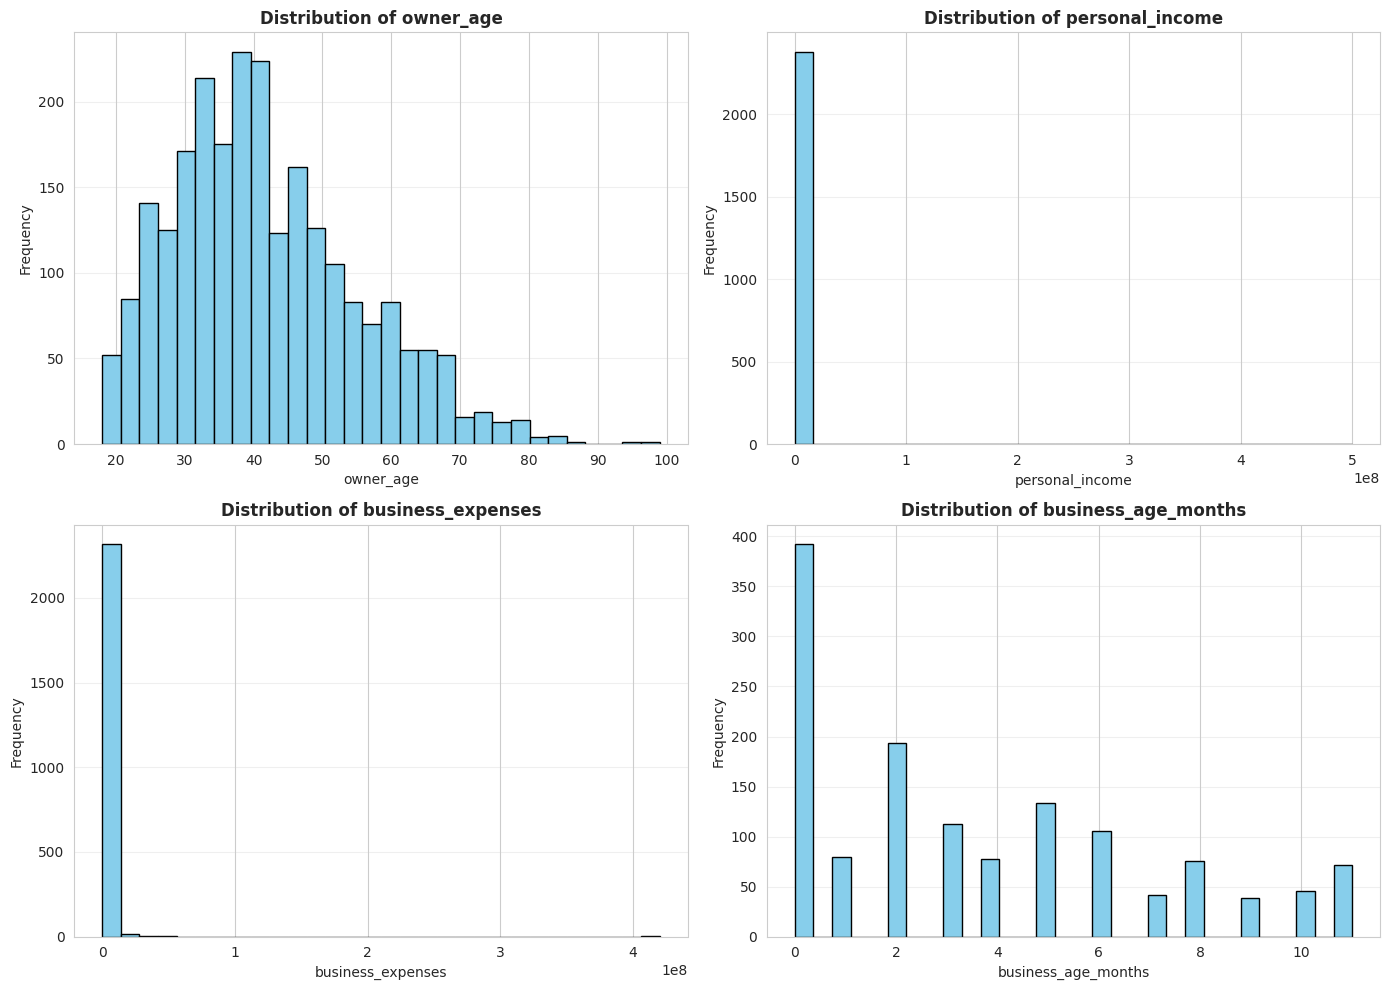

In [ ]:
# Identify numerical columns
numerical_cols = test_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Target' in numerical_cols:
    numerical_cols.remove('Target')
    pass

print(f"\nNumerical Features ({len(numerical_cols)}):")
display(numerical_cols)

# Statistical summary
print("\nStatistical Summary:")
# pd.set_option('display.float_format', '{:.9g}'.format)
display(test_df[numerical_cols].describe().style.format("{:.9g}"))

# Visualize distributions of key numerical features
key_numerical = ['owner_age', 'personal_income', 'business_expenses', 'business_age_months']
available_numerical = [col for col in key_numerical if col in test_df.columns]

if available_numerical:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for idx, col in enumerate(available_numerical[:4]):
        test_df[col].hist(bins=30, ax=axes[idx], color='skyblue', edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()



Comparing the training and test data sets, I note that the two generally follow the same trend. One might say that the test data set sample represents the population data set of SMEs and their business owners. If you look closely at the data, the two are not exactly the same. These two facts are very comforting.

## Categorical Feature Analysis

Having looked at the numerical features, we also want to peek into the non-numerical features or what are termed categorical features. By doing so, we hope to achieve the following:
* be guided in encoding strategy selection:
  - Low cardinality → One-hot encoding  
  - High cardinality → Target encoding, frequency encoding, or embedding-based approaches  
* be guided in identification of features that may:
  - Cause overfitting  
  - Increase model complexity unnecessarily  

Thus, we will be able to handle categorical features efficiently and appropriately in later stages. Previously, the columns were selected for having some kind of number format, the rest of the columns will have ````object```` data formats. We will drop the *ID* and *Target* columns, as the FHI has been looked at already, and the ID is a data entry/record label and has no descriptive value towards the explaining the target FHI variable.

In [ ]:
# Identify categorical columns
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
if 'ID' in categorical_cols:
    categorical_cols.remove('ID')
    pass

if 'Target' in categorical_cols:
    categorical_cols.remove('Target')
    pass

print(f"\nCategorical Features ({len(categorical_cols)}):")
display(categorical_cols)


Categorical Features (31):


['country',
 'attitude_stable_business_environment',
 'attitude_worried_shutdown',
 'compliance_income_tax',
 'perception_insurance_doesnt_cover_losses',
 'perception_cannot_afford_insurance',
 'motor_vehicle_insurance',
 'has_mobile_money',
 'current_problem_cash_flow',
 'has_cellphone',
 'owner_sex',
 'offers_credit_to_customers',
 'attitude_satisfied_with_achievement',
 'has_credit_card',
 'keeps_financial_records',
 'perception_insurance_companies_dont_insure_businesses_like_yours',
 'perception_insurance_important',
 'has_insurance',
 'covid_essential_service',
 'attitude_more_successful_next_year',
 'problem_sourcing_money',
 'marketing_word_of_mouth',
 'has_loan_account',
 'has_internet_banking',
 'has_debit_card',
 'future_risk_theft_stock',
 'medical_insurance',
 'funeral_insurance',
 'motivation_make_more_money',
 'uses_friends_family_savings',
 'uses_informal_lender']

The code above produced a list of size 31, the previous section initially produced a list of size 6. We expect our training data to have exactly 39 columns, and this is a sum total of 37 columns. But not to panic, this is accounted for in that we dropped two other variables, for the FHI target variable and the ID column. This gives us a total of 39 columns in the training data set, as we expect from our initial [data set overview](scrollTo=Data_Shape_and_Information).

In [ ]:
# Cardinality analysis
print("\nCardinality (Unique Values) for Categorical Features:")
cardinality_df = pd.DataFrame({
    'Feature': categorical_cols,
    'Unique_Values': [train_df[col].nunique() for col in categorical_cols]
}).sort_values('Unique_Values', ascending=False)
display(cardinality_df)


Cardinality (Unique Values) for Categorical Features:


,Feature,Unique_Values
26,medical_insurance,6
29,uses_friends_family_savings,6
30,uses_informal_lender,6
23,has_internet_banking,6
22,has_loan_account,6
13,has_credit_card,5
7,has_mobile_money,5
27,funeral_insurance,5
16,perception_insurance_important,5
15,perception_insurance_companies_dont_insure_bus...,5


We have already done this for the [target FHI variable](#scrollTo=Target_Variable_Analysis$0). Thus, we are kind of familiar with what we are looking for. We want to know how many different values each categorical feature could have taken on. Here we have simply counted the feature codes but we do not actually know what they are.

Printing out all the feature codes for all 31 columns might be too much. So, I have run some code to look at the feature codes for some. I added one more at the end of the iterative script to look more closely at *funeral_insurance* because I had noted this feature before in the [missing data analysis section](#scrollTo=Missing_Data_Analysis). I noted that almost 45% of the values were missing. From this feature count, this fact is proved to be true as the **Funeral Insurance Distribution** has 5 codes, for:
* Don't Know
* Have Now
* Never Had
* Used to Have But Don't Have Now
* Used to Have But Don`t Have Now

Here, the last two appear to be the same! And, there is a significant distribution of the entries slotted into either one of these last two codes. This is alarming. In addition, the count of 5 codes/labels did not include a NULL value or missing data label. We can begin to think more clearly about what this section is telling us about the data, as we look at the *Cardinality for Categorical Features* table above and the sample feature code/label tables below.

In [ ]:
for col in categorical_cols[:5]:
  print(f"{col} Distribution:")
  display(train_df[f'{col}'].value_counts().sort_index())
  print('\n')
  pass

print(f"Funeral Insurance Distribution:")
display(train_df['funeral_insurance'].value_counts().sort_index())

country Distribution:


,count
country,
eswatini,2674
lesotho,1944
malawi,2388
zimbabwe,2612




attitude_stable_business_environment Distribution:


,count
attitude_stable_business_environment,
Don’t know or N/A,1345
No,2451
Yes,5820




attitude_worried_shutdown Distribution:


...

,count
compliance_income_tax,
Don’t know,341
No,8010
Refused,11
Yes,1252




perception_insurance_doesnt_cover_losses Distribution:


,count
perception_insurance_doesnt_cover_losses,
Don't know,2523
No,4486
Yes,2604




Funeral Insurance Distribution:


,count
funeral_insurance,
Don't know,26
Have now,1608
Never had,3615
Used to have but don't have now,148
Used to have but don’t have now,33


I then duplicated my data into my working data set and an original training data (````Train_Original.csv````), untouched. This is standard data science practice. After thinking about the problem I found above, I decided to fix it. I realized that in fixing it, I might alter my data permanently, and not just the data as it is loaded into memory, while I am working on colab's Jupyter Notebook. Furthermore, as computation power is fairly cheap, I changed my mind and decided to print out the rest of the categorical data and not just the first 5 as I have done above. This will allow me to have a look at what I might find in the other features.

In [ ]:
for col in categorical_cols:
  print(f"{col} Distribution:")
  display(train_df[f'{col}'].value_counts().sort_index())
  print('\n')
  pass

country Distribution:


,count
country,
eswatini,2674
lesotho,1944
malawi,2388
zimbabwe,2612




attitude_stable_business_environment Distribution:


,count
attitude_stable_business_environment,
Don’t know or N/A,1345
No,2451
Yes,5820




attitude_worried_shutdown Distribution:


...

,count
motivation_make_more_money,
No,1865
Yes,3462




uses_friends_family_savings Distribution:


,count
uses_friends_family_savings,
Don't know,2
Don’t know (Do not show),3
Have now,529
Never had,2895
Used to have but don't have now,1396
Used to have but don’t have now,305




uses_informal_lender Distribution:


,count
uses_informal_lender,
Don't know,2
Don’t know (Do not show),4
Have now,214
Never had,2864
Used to have but don't have now,1738
Used to have but don’t have now,307


As I suspected, nonsensical categories occur in the other features as well. Responses for features like *attitude_worried_shutdown* like *Yes*, *No*, and *Don't Know/Not Applicable* are acceptable. I found that responses for features like *compliance_income_tax* *Yes*, and *No* made sense. But maybe saying *Don't Know* and *Refused* might be the same thing. However, I will not penalize the person whom designed the survey for this logical choice as they might be an expert, and they understand how the respondents with a business at stake might wish to respond. Looking at the rest of the categorical features, I found that the following features demonstrated the same problem as discovered in the *funeral_insurance* feature above, when I only displayed the first 5 categorical features;
* *has_mobile_money*,
* *has_credit_card*,
* *has_loan_account*,
* *has_internet_banking*,
* *has_debit_card*,
* *medical_insurance*,
* *uses_friends_family_savings*,
* and *uses_informal_lender*

In addition, a feature called *current_problem_cash_flow* produced a *0* category with a count of 1,265 of the overall dataset. Previously, the same cateogry had a *null value* count of 39%, or 3,778 missing values. This *0* category is not the same as the *null value* count. I used a spreadsheet program to confirm what I was seeing using code. I sorted the *current_problem_cashflow* column and browsed the entries. This category does exist in addition to the missing values. I have no reference point to be able to tell if the *0* entry was infact an *I don't know* or a "Not Applicable* option in the original survey. This information is not provided along with the dataset (maybe in the *variable definitions* csv file).

Other feature issues that I discovered include:
* duplicate categories of *I don't know* and *I don't know/Not Applicable*. These two could be one, or completely separate. I might make the choice to make them one or to make the duplicate simply *Not Applicable*. Features with this issue are:
    * *attitude_satisfied_with_achievement*
    * *attitude_more_successful_next_year*

    In the list above, the category label problem is the same as in the list that will follow. This makes me want to believe it is intentional. The labels will be merged as saying *I do not know OR Not Applicable* as this is the same as saying *I do not know*. Once merged they should be *I do not know/Not Applicable*.

* duplicate categories of *I don't know* and *I don't know (Do not Show)*. I need more information to understand what "Do not show" refers to. Features with this issue are:
    * *has_loan_account*
    * *has_internet_banking*
    * *medical_insurance*
    * *uses_friends_family_savings*
    * *uses_informal_lender*

    In the list above, the category label *I do not know (Do not show)* could be intentional as the issue is duplicated in all these features. But nothing in the data gives us insight into what this category label could mean and we need a sample of the original survey to learn more. For now, it will be merged into one with simply *I don't know*.

* duplicate response categories of *yes*, *yes, sometimes*, and *yes, always*. Here, *yes* and *yes, always* might be assumed to be the same. But it is also possible that some selected a *yes* to mean sometimes, though unlikely. Without further information, it might be hard to fix this category. I will fix it for now, but might revert it later and note it as a survey design issue. Features with this issue are:
    * *keeps_financial_records*

* categorical response options were *Do not know/Not Applicable*, *Don't know*, *Don't know/Doesn't Apply*, *No*, and *Yes*. Clearly, the first and third are duplicates of each other. Then, theoretically, the second is the same as the other two. Unless everyone whom selected any of the other two, exclusively meant to indicate that this question was not applicable to them. Features with this issue are:
    * *perception_insurance_important*
    * *perception_insurance_companies_dont_insure_businesses_like_yours*

Some features appeared in more than one of the lists developed above. To resolve the first issue, I have looked more closely at the label and discovered that the issue was actually an odd character. There are different types of apostrophes on keyboards, and in this case, two different ones have been entered in the data, which the system distinguishes.



In [ ]:
for col in categorical_cols:
  # Fix Duplicate Label Issue: Used to have but don't have now
  train_df[col] = train_df[col].str.replace(r"’", "'", regex=True)
  pass

# Merge I Don't Know and I Don't Know/Not Applicable
train_df['attitude_satisfied_with_achievement'] = train_df['attitude_satisfied_with_achievement'].str.replace(r"^Don't know$", "Don’t know or N/A", regex=True).replace(r"’", "'", regex=True)
train_df['attitude_more_successful_next_year'] = train_df['attitude_more_successful_next_year'].str.replace(r"^Don't know$", "Don’t know or N/A", regex=True).replace(r"’", "'", regex=True)

# Merge I Don't Know and I Don't Know (Do Not Show)
train_df['has_loan_account'] = train_df['has_loan_account'].str.replace(r"^Don't know$", "Don’t know (Do not show)", regex=True).replace(r"’", "'", regex=True)
train_df['has_internet_banking'] = train_df['has_internet_banking'].str.replace(r"^Don't know$", "Don’t know (Do not show)", regex=True).replace(r"’", "'", regex=True)
train_df['medical_insurance'] = train_df['medical_insurance'].str.replace(r"^Don't know$", "Don’t know (Do not show)", regex=True).replace(r"’", "'", regex=True)
train_df['uses_friends_family_savings'] = train_df['uses_friends_family_savings'].str.replace(r"^Don't know$", "Don’t know (Do not show)", regex=True).replace(r"’", "'", regex=True)
train_df['uses_informal_lender'] = train_df['uses_informal_lender'].str.replace(r"^Don't know$", "Don’t know (Do not show)", regex=True).replace(r"’", "'", regex=True)

# Merge I Don't Know, I Don't Know/NA, and I Don't Know/Doesn't Apply
train_df['perception_insurance_important'] = train_df['perception_insurance_important'].str.replace(r"’", "'", regex=True).replace(r"\?", "\'", regex=True).replace(r"^Don't Know$", "Do not know / N/A", regex=True).replace(r"^Don't know / doesn't apply$", "Do not know / N/A", regex=True)
train_df['perception_insurance_companies_dont_insure_businesses_like_yours'] = train_df['perception_insurance_companies_dont_insure_businesses_like_yours'].str.replace(r"’", "'", regex=True).replace(r"\?", "\'", regex=True).replace(r"^Don't [Kk]now$", "Do not know / N/A", regex=True).replace(r"^Don't know / doesn't apply$", "Do not know / N/A", regex=True)

# Merge Yes and Yes, always
train_df['keeps_financial_records'] = train_df['keeps_financial_records'].str.replace(r"^Yes$", "Yes, always", regex=True)


pattern = r'[\u200b\u00a0\u200e]'
train_df[categorical_cols] = train_df[categorical_cols].apply(lambda x : x.str.replace(pattern, '', regex=True).str.strip())

for col in categorical_cols:
  print(f"{col} Distribution:")
  display(train_df[f'{col}'].value_counts().sort_index())
  print('\n')
  pass

country Distribution:


,count
country,
eswatini,2674
lesotho,1944
malawi,2388
zimbabwe,2612




attitude_stable_business_environment Distribution:


,count
attitude_stable_business_environment,
Don't know or N/A,1345
No,2451
Yes,5820




attitude_worried_shutdown Distribution:


...

,count
motivation_make_more_money,
No,1865
Yes,3462




uses_friends_family_savings Distribution:


,count
uses_friends_family_savings,
Don't know (Do not show),5
Have now,529
Never had,2895
Used to have but don't have now,1701




uses_informal_lender Distribution:


,count
uses_informal_lender,
Don't know (Do not show),6
Have now,214
Never had,2864
Used to have but don't have now,2045


As I have done in the previous [Numerical Feature Analysis](#scrollTo=Numerical_Features_Analysis) section, I have decided to peek into all the categorical features of the test data set, just to see if I might find something interesting at this exploratory phase. I initially printed the distribution of the labels of each categorical feature before making amendments. In doing so, I discovered a very interesting anomaly with the *funeral_insurance* category in the test data set, this was confirmed by the cardinality analysis, but it was easy to miss. I discovered that this feature has 6 labels/codes rather than the 5 found in the training data. What is surprising is that the extra label is *Don't Know (Don't Show)*. This seems to support my decision to combine simple labels *Don't Know* with the complex label *Don't Know (Don't Show)* in the feature set of the training data. I was going to replicate that here, infact, the code was copied exactly from the previous stage in this section. However, having discovered this anomaly, I was made aware that others might exist that I am not treating for. Thus, *funeral_insurance* will now have to have it's labels combined as this step is manual. Fortunately, after checking the other categorical feature distributions, I was assured that this was the only anomaly!

In [ ]:
# Identify categorical columns
categorical_cols = test_df.select_dtypes(include=['object']).columns.tolist()
if 'ID' in categorical_cols:
    categorical_cols.remove('ID')
    pass

if 'Target' in categorical_cols:
    categorical_cols.remove('Target')
    pass

print(f"\nCategorical Features ({len(categorical_cols)}):")
display(categorical_cols)

# Cardinality analysis
print("\nCardinality (Unique Values) for Categorical Features:")
cardinality_df = pd.DataFrame({
    'Feature': categorical_cols,
    'Unique_Values': [test_df[col].nunique() for col in categorical_cols]
}).sort_values('Unique_Values', ascending=False)
display(cardinality_df)

# Used to check and the same types of errors were found in the test data set. Thus to reduce my print out, I simply removed this block of code
"""
for col in categorical_cols:
  print(f"{col} Distribution:")
  display(test_df[f'{col}'].value_counts().sort_index())
  print('\n')
  pass
"""

for col in categorical_cols:
  # Fix Duplicate Label Issue: Used to have but don't have now
  test_df[col] = test_df[col].str.replace(r"’", "'", regex=True)
  pass

# Merge I Don't Know and I Don't Know/Not Applicable
test_df['attitude_satisfied_with_achievement'] = test_df['attitude_satisfied_with_achievement'].str.replace(r"^Don't know$", "Don’t know or N/A", regex=True).replace(r"’", "'", regex=True)
test_df['attitude_more_successful_next_year'] = test_df['attitude_more_successful_next_year'].str.replace(r"^Don't know$", "Don’t know or N/A", regex=True).replace(r"’", "'", regex=True)

# Merge I Don't Know and I Don't Know (Do Not Show)
test_df['has_loan_account'] = test_df['has_loan_account'].str.replace(r"^Don't know$", "Don’t know (Do not show)", regex=True).replace(r"’", "'", regex=True)
test_df['has_internet_banking'] = test_df['has_internet_banking'].str.replace(r"^Don't know$", "Don’t know (Do not show)", regex=True).replace(r"’", "'", regex=True)
test_df['medical_insurance'] = test_df['medical_insurance'].str.replace(r"^Don't know$", "Don’t know (Do not show)", regex=True).replace(r"’", "'", regex=True)
test_df['uses_friends_family_savings'] = test_df['uses_friends_family_savings'].str.replace(r"^Don't know$", "Don’t know (Do not show)", regex=True).replace(r"’", "'", regex=True)
test_df['uses_informal_lender'] = test_df['uses_informal_lender'].str.replace(r"^Don't know$", "Don’t know (Do not show)", regex=True).replace(r"’", "'", regex=True)

# Extra of the above feature code
test_df['funeral_insurance'] = test_df['funeral_insurance'].str.replace(r"^Don't know$", "Don’t know (Do not show)", regex=True).replace(r"’", "'", regex=True)

# Merge I Don't Know, I Don't Know/NA, and I Don't Know/Doesn't Apply
test_df['perception_insurance_important'] = test_df['perception_insurance_important'].str.replace(r"’", "'", regex=True).replace(r"\?", "\'", regex=True).replace(r"^Don't Know$", "Do not know / N/A", regex=True).replace(r"^Don't know / doesn't apply$", "Do not know / N/A", regex=True)
test_df['perception_insurance_companies_dont_insure_businesses_like_yours'] = test_df['perception_insurance_companies_dont_insure_businesses_like_yours'].str.replace(r"’", "'", regex=True).replace(r"\?", "\'", regex=True).replace(r"^Don't [Kk]now$", "Do not know / N/A", regex=True).replace(r"^Don't know / doesn't apply$", "Do not know / N/A", regex=True)

# Merge Yes and Yes, always
test_df['keeps_financial_records'] = test_df['keeps_financial_records'].str.replace(r"^Yes$", "Yes, always", regex=True)


pattern = r'[\u200b\u00a0\u200e]'
test_df[categorical_cols] = test_df[categorical_cols].apply(lambda x : x.str.replace(pattern, '', regex=True).str.strip())

for col in categorical_cols:
  print(f"{col} Distribution:")
  display(test_df[f'{col}'].value_counts().sort_index())
  print('\n')
  pass


Categorical Features (31):


['country',
 'attitude_stable_business_environment',
 'attitude_worried_shutdown',
 'compliance_income_tax',
 'perception_insurance_doesnt_cover_losses',
 'perception_cannot_afford_insurance',
 'motor_vehicle_insurance',
 'has_mobile_money',
 'current_problem_cash_flow',
 'has_cellphone',
 'owner_sex',
 'offers_credit_to_customers',
 'attitude_satisfied_with_achievement',
 'has_credit_card',
 'keeps_financial_records',
 'perception_insurance_companies_dont_insure_businesses_like_yours',
 'perception_insurance_important',
 'has_insurance',
 'covid_essential_service',
 'attitude_more_successful_next_year',
 'problem_sourcing_money',
 'marketing_word_of_mouth',
 'has_loan_account',
 'has_internet_banking',
 'has_debit_card',
 'future_risk_theft_stock',
 'medical_insurance',
 'funeral_insurance',
 'motivation_make_more_money',
 'uses_friends_family_savings',
 'uses_informal_lender']


Cardinality (Unique Values) for Categorical Features:


,Feature,Unique_Values
27,funeral_insurance,6
13,has_credit_card,5
7,has_mobile_money,5
16,perception_insurance_important,5
22,has_loan_account,5
15,perception_insurance_companies_dont_insure_bus...,5
24,has_debit_card,5
29,uses_friends_family_savings,5
23,has_internet_banking,5
26,medical_insurance,5


country Distribution:


...

,count
motivation_make_more_money,
No,457
Yes,864




uses_friends_family_savings Distribution:


,count
uses_friends_family_savings,
Don't know (Do not show),2
Have now,133
Never had,709
Used to have but don't have now,430




uses_informal_lender Distribution:


,count
uses_informal_lender,
Have now,52
Never had,714
Used to have but don't have now,508


I am once again satisfied that the test data set is as the training data set for this part of my exploratory data analysis.

## Country Feature Analysis

So far, we have narrowed down our analysis to the training data set, as guided by the starter notebook from Zindi.Africa. For this section, we will look at the data in both the training and testing data set. We are looking more closely at the *country* feature. The section above confirmed many times that we are looking at four countries in this study and that they are;
* Eswatini
* Lesotho
* Malawi
* Zimbabwe




Train Set Country Distribution:


,count
country,
eswatini,2674
zimbabwe,2612
malawi,2388
lesotho,1944



Test Set Country Distribution:


,count
country,
eswatini,669
zimbabwe,653
malawi,597
lesotho,486


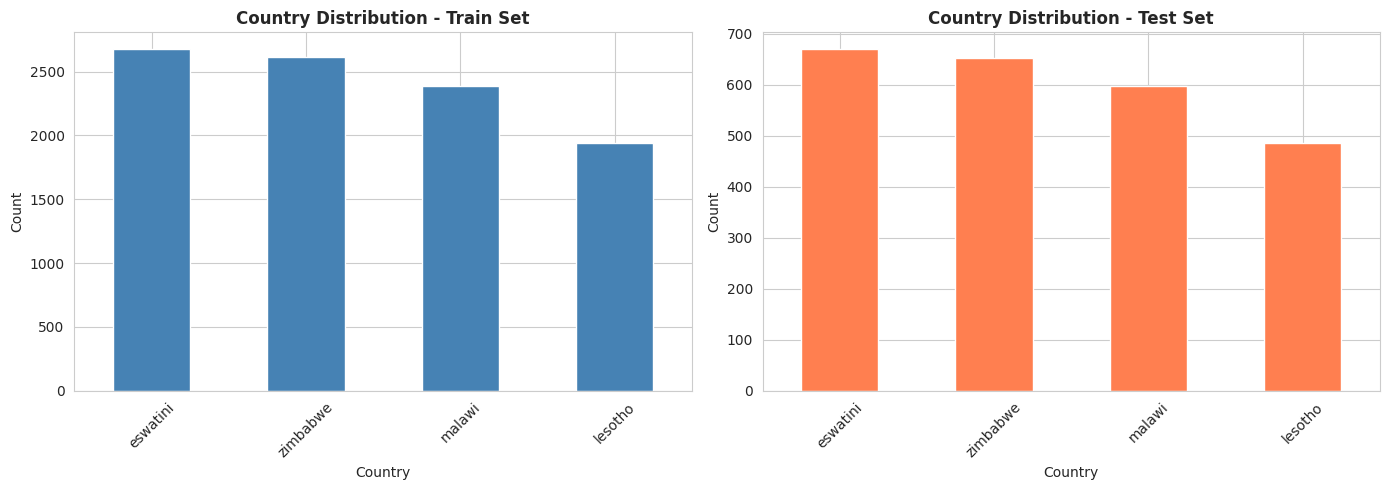

In [ ]:
if 'country' in train_df.columns and 'country' in test_df.columns:
  train_df_country_count = train_df['country'].value_counts()
  test_df_country_count = test_df['country'].value_counts()

  print("\nTrain Set Country Distribution:")
  display(train_df_country_count)

  print("\nTest Set Country Distribution:")
  display(test_df_country_count)

  # Visualize
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  train_df_country_count.plot(kind='bar', ax=axes[0], color='steelblue')
  axes[0].set_title('Country Distribution - Train Set', fontsize=12, fontweight='bold')
  axes[0].set_xlabel('Country')
  axes[0].set_ylabel('Count')
  axes[0].tick_params(axis='x', rotation=45)

  test_df_country_count.plot(kind='bar', ax=axes[1], color='coral')
  axes[1].set_title('Country Distribution - Test Set', fontsize=12, fontweight='bold')
  axes[1].set_xlabel('Country')
  axes[1].set_ylabel('Count')
  axes[1].tick_params(axis='x', rotation=45)

  plt.tight_layout()
  plt.show()
  pass

Looking at the table, the values in the test data set are clearly lower than those in the training data set, as previously revealed by the [data overview](#scrollTo=Data_Shape_and_Information), which showed us that the test data set had a significantly lower record count. The *country distribution* graphs produced below the *country dsitrbution* tables show something interesting. The training and test data set appear to have the same distribution of records among the four countries for which data was collected.

This relationship was confirmed by producing a distribution table of percentages below and it shows that the distributions or proportions of the countries are replicated among the datasets.

In [ ]:
if 'country' in train_df.columns and 'country' in test_df.columns:
  train_df_country_pct = ((train_df['country'].value_counts()/ train_df.shape[0]) * 100).to_frame(name='percentage')
  test_df_country_pct = ((test_df['country'].value_counts() /test_df.shape[0]) * 100).to_frame(name='percentage')

  #pd.options.display.float_format = '{:,.2f}'.format
  print("\nTrain Set Country Distribution:")
  display(train_df_country_pct.style.format({'percentage': '{:.2f}%'}))

  print("\nTest Set Country Distribution:")
  display(test_df_country_pct.style.format({'percentage': '{:.2f}%'}))

  pass


Train Set Country Distribution:


,percentage
country,
eswatini,27.80%
zimbabwe,27.16%
malawi,24.83%
lesotho,20.21%



Test Set Country Distribution:


,percentage
country,
eswatini,27.82%
zimbabwe,27.15%
malawi,24.82%
lesotho,20.21%


## Binary or Categorical Feature Analysis

In [ ]:
# Analyze Yes/No columns
yes_no_cols = [col for col in categorical_cols if
               train_df[col].dropna().isin(['Yes', 'No', "Don't know or N/A"]).any()]

print(f"\nYes/No Type Columns ({len(yes_no_cols)}):")
for col in yes_no_cols:
    print(f"\n{col}:")
    print(train_df[col].value_counts())


Yes/No Type Columns (19):

attitude_stable_business_environment:
attitude_stable_business_environment
Yes                  5820
No                   2451
Don't know or N/A    1345
Name: count, dtype: int64

attitude_worried_shutdown:
attitude_worried_shutdown
No                   5804
Yes                  3575
Don't know or N/A     237
Name: count, dtype: int64

compliance_income_tax:
compliance_income_tax
No            8010
Yes           1252
Don't know     341
Refused         11
Name: count, dtype: int64

perception_insurance_doesnt_cover_losses:
perception_insurance_doesnt_cover_losses
No            4486
Yes           2604
Don't know    2523
Name: count, dtype: int64

perception_cannot_afford_insurance:
perception_cannot_afford_insurance
Yes           6056
No            2093
Don't know    1464
Name: count, dtype: int64

current_problem_cash_flow:
current_problem_cash_flow
Yes    2688
No     1887
0      1265
Name: count, dtype: int64

has_cellphone:
has_cellphone
Yes    6203
No     

Having discovered the rather shallow analysis being undertaken here, I had repeated this step as is from the Zindi.Africa notebook. However, I recalled the issue I encountered with printing out limited data in the [Categorical Feature Analysis](#scrollTo=Categorical_Feature_Analysis$0) section. Here we simply iterated through the previously identified categorical columns, dropped columns with missing values, and then returned the columns that pass as being of a binary or tenary type.

According to the notebook, this is important because:
* Binary features are straightforward to encode but they might still require:
  * Handling missing values (Don't know or N/A)
  * Balancing skewed responses
* Understanding their distribution helps ensure proper preprocessing for modeling.


## Explopring Key Features


This section examines how key features relate to the target variable (`FHI`) to identify potential predictors and patterns. The features are examined according to how we have grouped them previously. Recall in the introduction that we had outlined 4 categories of features that we wish to be a part of our investigation/research. The numerical features have all been selected for inclusion in our study. Thus we will compute, the *mean*, *median*, *standard deviation, and *count* of numerical features grouped by each of the labels in the `FHI` target variable.

According to the starter notebook, this is supposed to help us to detect:
  * Trends or differences between classes  
  * Features that may have strong predictive power  
  * Variability that could influence model performance

In [ ]:
# ========================================
# NUM FEATURE RELATIONSHIP WITH TARGET
# ========================================

if 'Target' in train_df.columns:
    # Numerical features vs target
    print("\nNumerical Features by Target:")
    if available_numerical:
        for col in available_numerical:  # ALL
            print(f"\n{col} by Target:")
            grouped_stats = train_df.groupby('Target')[col].agg(['mean', 'median', 'std', 'count'])
            print(grouped_stats)


Numerical Features by Target:

owner_age by Target:
             mean  median        std  count
Target                                     
High    44.610638    42.0  11.881589    470
Low     40.732962    39.0  13.333695   6280
Medium  43.358438    42.0  13.264731   2868

personal_income by Target:
                 mean  median           std  count
Target                                            
High    882802.239224  5000.0  4.715191e+06    464
Low     254094.823039  2000.0  2.546815e+06   6209
Medium  180199.970205  1500.0  2.045196e+06   2836

business_expenses by Target:
                mean   median           std  count
Target                                            
High    1.062801e+06  10100.0  8.584024e+06    464
Low     4.855686e+05   3000.0  6.866861e+06   6137
Medium  2.979526e+05   2000.0  3.564138e+06   2788

business_age_months by Target:
            mean  median       std  count
Target                                   
High    4.543243     4.0  3.252603    370
L

Then, we will also produce statistics of some categorical features against the target 'FHI' index variable. This time, the notebook guided us to select 3 key features from the 31 identified before. These are:
* country
* compliance_income_tax
* medical_insurance

In [ ]:
# ========================================
# KEY CAT FEATURE RELATIONSHIP WITH TARGET
# ========================================

if 'Target' in train_df.columns:
    # Categorical features vs target
    print("\nKey Categorical Features by Target:")
    key_cat = ['country', 'compliance_income_tax', 'medical_insurance']
    for col in key_cat:
        if col in train_df.columns:
            print(f"\n{col} distribution by Target:")
            ct = pd.crosstab(train_df[col], train_df['Target'], normalize='index') * 100
            print(ct.round(2))


Key Categorical Features by Target:

country distribution by Target:
Target     High    Low  Medium
country                       
eswatini  11.48  51.42   37.10
lesotho    0.31  60.39   39.30
malawi     4.02  81.24   14.74
zimbabwe   2.34  68.57   29.10

compliance_income_tax distribution by Target:
Target                  High    Low  Medium
compliance_income_tax                      
Don't know              1.76  75.07   23.17
No                      3.17  68.18   28.65
Refused                 0.00  90.91    9.09
Yes                    16.77  44.09   39.14

medical_insurance distribution by Target:
Target                            High    Low  Medium
medical_insurance                                    
Don't know (Do not show)          0.00  82.35   17.65
Have now                         23.51   0.00   76.49
Never had                         6.53  64.25   29.22
Used to have but don't have now   6.51  38.14   55.35


As with the numerical features, we have produced a chart that will allow us to compare labels from each feature against the labels of the categorical 'FHI' index target variable. The table/chart produced is called a cross-tabulation and we used the ````crosstab```` function; with the target variable along the columns, and the feature labels running along the rows (as the index). The values in the cells are frequencies, or percentage count values.

This step was done to help us understand feature-target relationships. Features that demonstrate a association with the 'FHI' target will be prime candidates for inclusion in the predictive model we will choose for this assignment. The notebook makes the note that this analysis will provide a foundation for **data-driven feature engineering** and help us to prioritize which features may drive predictive performance. I ran the code above again below incase I misunderstood the goals of this section. I did not, but I need to check or confirm that the features selected in the notebook satisfy the requirements that we have been given.


In [ ]:
# ========================================
# ALL CATEGORICAL FEATURE RELATIONSHIP WITH TARGET
# ========================================

if 'Target' in train_df.columns:
    # Categorical features vs target
    print("\nAll Categorical Features by Target:")
    for col in categorical_cols:
        if col in train_df.columns:
            print(f"\n{col} distribution by Target:")
            ct = pd.crosstab(train_df[col], train_df['Target'], normalize='index') * 100
            print(ct.round(2))


All Categorical Features by Target:

country distribution by Target:
Target     High    Low  Medium
country                       
eswatini  11.48  51.42   37.10
lesotho    0.31  60.39   39.30
malawi     4.02  81.24   14.74
zimbabwe   2.34  68.57   29.10

attitude_stable_business_environment distribution by Target:
Target                                High    Low  Medium
attitude_stable_business_environment                     
Don't know or N/A                     3.64  76.65   19.70
No                                    4.73  67.48   27.78
Yes                                   5.24  61.74   33.02

attitude_worried_shutdown distribution by Target:
Target                     High    Low  Medium
attitude_worried_shutdown                     
Don't know or N/A          5.06  67.51   27.43
No                         5.27  62.06   32.67
Yes                        4.25  70.38   25.37

compliance_income_tax distribution by Target:
Target                  High    Low  Medium
compliance_inco

## Data Quality Checks

Largely, data quality checks have been done up until this point, as we explored our data. Recall, we changed some labels in the [Categorical Feature Analysis](#scrollTo=Categorical_Feature_Analysis) stage. But I allowed myself to go through it again as guided by the notebook. Steps involved are:
* Checks for Duplicate IDs:
  * Counts **duplicate IDs** in both train and test sets
  * Duplicate IDs may indicate repeated records

* Train-Test ID Overlap:
  * helps to identify IDs present in both train data set and test data set
  * though the concept of data leakage is not clear, it is clear that overlapping IDs could lead to inflated model performance

* Consistency Check for Features:
  * Compare columns in train and test datasets (excluding the target `FHI`)  
  * Detect:
    * Features present in train but missing in test  
    * Features present in test but missing in train  
  * Ensures that both datasets are aligned for modeling  

All in all this should allow us to confirm that the datasets are clean, consistent, and free from critical integrity issues. It will prevent modelling errors due to missing features, and unexpected mismatches during prediction.

In [ ]:
# ========================================
# DATA QUALITY CHECKS
# ========================================
# Check for duplicate IDs
print(f"\nDuplicate IDs in Train: {train_df['ID'].duplicated().sum()}")
print(f"Duplicate IDs in Test: {test_df['ID'].duplicated().sum()}")

# Check for ID overlap
id_overlap = set(train_df['ID']).intersection(set(test_df['ID']))
print(f"Overlapping IDs between Train and Test: {len(id_overlap)}")

# Check feature consistency
train_cols = set(train_df.columns) - {'Target'}
test_cols = set(test_df.columns)
missing_in_test = train_cols - test_cols
extra_in_test = test_cols - train_cols

if missing_in_test:
    print(f"\n⚠ Features in Train but not in Test: {missing_in_test}")
if extra_in_test:
    print(f"\n⚠ Features in Test but not in Train: {extra_in_test}")
if not missing_in_test and not extra_in_test:
    print("\n✓ Feature sets are consistent.")


Duplicate IDs in Train: 0
Duplicate IDs in Test: 0
Overlapping IDs between Train and Test: 0

✓ Feature sets are consistent.


As the summary above tells us, there are no duplicate data records by ID in both data sets, and there are no overlapping IDs between the two datasets. Thus, we are sure that we do not have repeated records in individual data sets nor repeating by occuring in both data sets that would skew the results of our training and testing. So we are happy with the data thus far.

## Summary

In [ ]:
# ========================================
# SUMMARY
# ========================================
print("Exploratory Data Analysis SUMMARY:")
print("="*60)
print(f"Total training samples: {len(train_df):,}")
print(f"Total test samples: {len(test_df):,}")
print(f"Number of features: {len(categorical_cols) + len(numerical_cols)}")
print(f"Numerical features: {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

if len(train_missing) > 0:
    print(f"\nMissing Data:")
    print(f"Features with missing values: {len(train_missing)}")
    print(f"Highest missing percentage: {train_missing['Percentage'].max():.1f}%")

Exploratory Data Analysis SUMMARY:
Total training samples: 9,618
Total test samples: 2,405
Number of features: 37
Numerical features: 6
Categorical features: 31

Missing Data:
Features with missing values: 35
Highest missing percentage: 46.7%


As this is a summary section of our exploratory data analysis, we will want to use the output above to think about:

* Handling missing values
* Encoding categorical variables
* Scaling numerical features if needed
* Considering feature engineering based on domain knowledge
* Handling class imbalance if present
* Training baseline models and iterating!!

# Feature Engineering

## Sample Feature(s)

This section was interesting as Zindi.Africa walked us through creating a new feature using the current data. There was no other way to go about it but to make use of the steps provided in the starter notebook. With more understanding of your data set, and statistical mathematics, such a feat should be possible. You need both skills because you have to know what you have to work with and you have to create a feature that has relevance or business sense. One might consider a valuation tool from one of the following ratio categories from the fields of business, economics, and/or finance:
* liquidity ratios,
* leverage ratios,
* efficiency ratios,
* profitability ratios,
* or market value ratios

### Profit Margin Ratio


This is a profitability ratio which measures business profitability relative to income. It is calculated as follows:

$$profit\_margin\_ratio = \frac{(personal\_income - business\_expenses)}{ personal\_income}$$

This ratio indicates financial efficiency and sustainability. Higher values of the ratio suggest better financial health, while lower values suggest the opposite. It can help the model to distinguish between a healthy business and a struggling business.

The function for the calculation above has been replicated below.

In [ ]:
def compute_profit_margin_ratio(personal_income : Decimal, business_expenses: Decimal) -> Decimal | None:
  if (personal_income == 0) or personal_income is None or math.isnan(personal_income):
    return None
  return ((personal_income - business_expenses)/ personal_income)

#### Training Dataset

In [ ]:
train_df['profit_margin_ratio'] = train_df.apply(
    lambda row: compute_profit_margin_ratio(row['personal_income'], row['business_expenses']),
    axis=1
)

It appears as though my formula executed without throwing an error. I played around with including the check/test for a zero value in the original ````compute_profit_margin_ratio```` function. But it would not play nice in the end, and to save time, I accepted this solution. Sometimes, I have the fear that my solutions appear too sophisticated to be my own work. But then again, i am about to train a MODEL on this data.

In [ ]:
display(train_df.head())

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target,profit_margin_ratio
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,...,Never had,NaN,6.0,Never had,Used to have but don't have now,NaN,Never had,Never had,Low,-1.000000
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,...,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium,NaN
2,ID_TY93LV,malawi,34.0,Don't know or N/A,No,No,Don't know,Yes,30000.0,6000.0,...,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low,0.800000
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,...,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low,0.666667
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,...,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low,-47.000000


It appears again as though my feature creation worked.

In [ ]:
categories_feature_1 = ['personal_income', 'business_expenses', 'profit_margin_ratio']
train_df[categories_feature_1].describe().style.format("{:.9g}")

,personal_income,business_expenses,profit_margin_ratio
count,9509,9389,9338
mean,262734.474,458383.845,-9.69300946
std,2566268.07,6184746.45,95.1683125
min,0,0,-7199
25%,300,700,-5
50%,2000,3000,-0.285714286
75%,25000,25000,0.6
max,150000000,500000000,1



TRAIN SET FEATURE 1 - Columns with Missing Values:
             Column  Missing_Count  Percentage
profit_margin_ratio            280    2.911208
  business_expenses            229    2.380952
    personal_income            109    1.133292



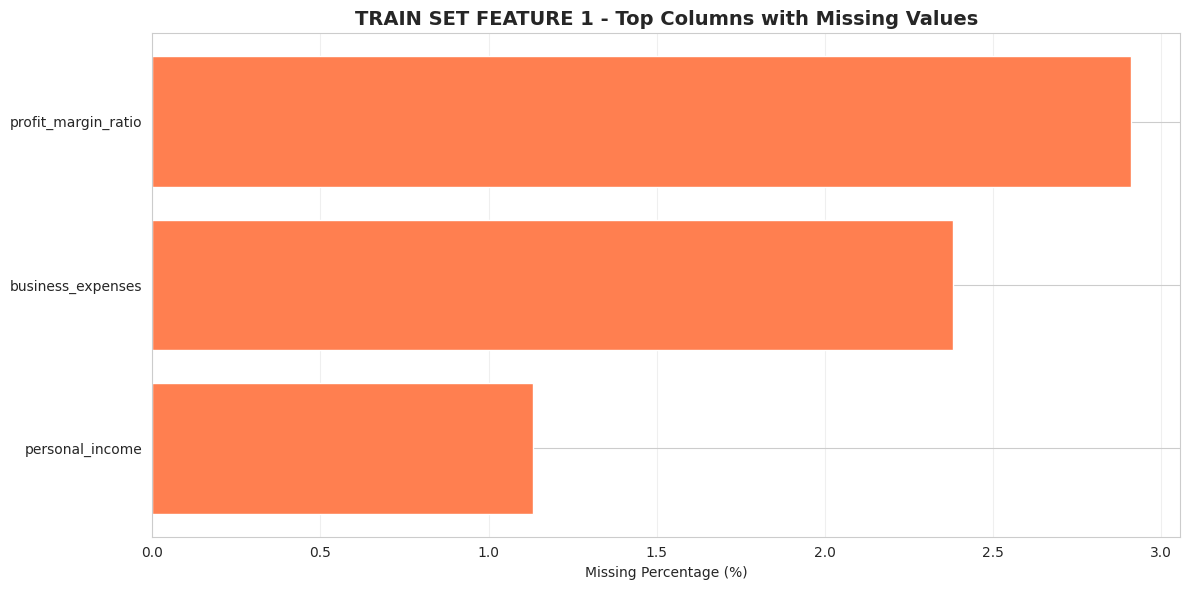

,Column,Missing_Count,Percentage
2,profit_margin_ratio,280,2.911208
1,business_expenses,229,2.380952
0,personal_income,109,1.133292


In [ ]:
analyze_missing(train_df[categories_feature_1], "TRAIN SET FEATURE 1")

Above, I wanted to visualize the kind of missing data errors that were reproduced from the other variables into my engineered feature. I am somewhat happy with what I see, I can explain the missing values scenario. I am not so excited about the statistics produced using ````describe````. At best, someone has an income, and no business expenses (ratio = 1), and the minimum or worst ratio is about ~7000 timees the magnitude of the best in the opposite direction.

#### Testing Dataset

In [ ]:
test_df['profit_margin_ratio'] = test_df.apply(
    lambda row: compute_profit_margin_ratio(row['personal_income'], row['business_expenses']),
    axis=1
)

In [ ]:
display(test_df.head())

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,profit_margin_ratio
0,ID_5EGLKX,zimbabwe,50.0,No,No,No,No,Yes,100.0,3600.0,...,NaN,NaN,No,8.0,Never had,Never had,NaN,NaN,NaN,-35.000000
1,ID_4AI7RE,lesotho,36.0,Yes,Yes,No,Yes,Yes,900.0,400.0,...,NaN,NaN,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now,0.555556
2,ID_V9OB3M,lesotho,25.0,Don't know or N/A,No,No,Don't know,Don't know,5250.0,350.0,...,Have now,Have now,Yes,NaN,NaN,NaN,No,Never had,Used to have but don't have now,0.933333
3,ID_6OI9DI,malawi,25.0,Don't know or N/A,Yes,No,No,Yes,485000.0,10000.0,...,Never had,Never had,Yes,NaN,NaN,NaN,Yes,Have now,Never had,0.979381
4,ID_H2TN8B,lesotho,47.0,No,Yes,No,Don't know,Don't know,97.0,500.0,...,Have now,Have now,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now,-4.154639


In [ ]:
categories_feature_1 = ['personal_income', 'business_expenses', 'profit_margin_ratio']
test_df[categories_feature_1].describe().style.format("{:.9g}")

,personal_income,business_expenses,profit_margin_ratio
count,2382,2335,2322
mean,463016.019,573308.392,-7.65463936
std,10496422,8976428.95,51.2202807
min,0,0,-2060.85567
25%,400,700,-5
50%,2000,3000,-0.2
75%,30000,30000,0.627849315
max,500000000,420000000,1



TEST SET FEATURE 1 - Columns with Missing Values:
             Column  Missing_Count  Percentage
profit_margin_ratio             83    3.451143
  business_expenses             70    2.910603
    personal_income             23    0.956341



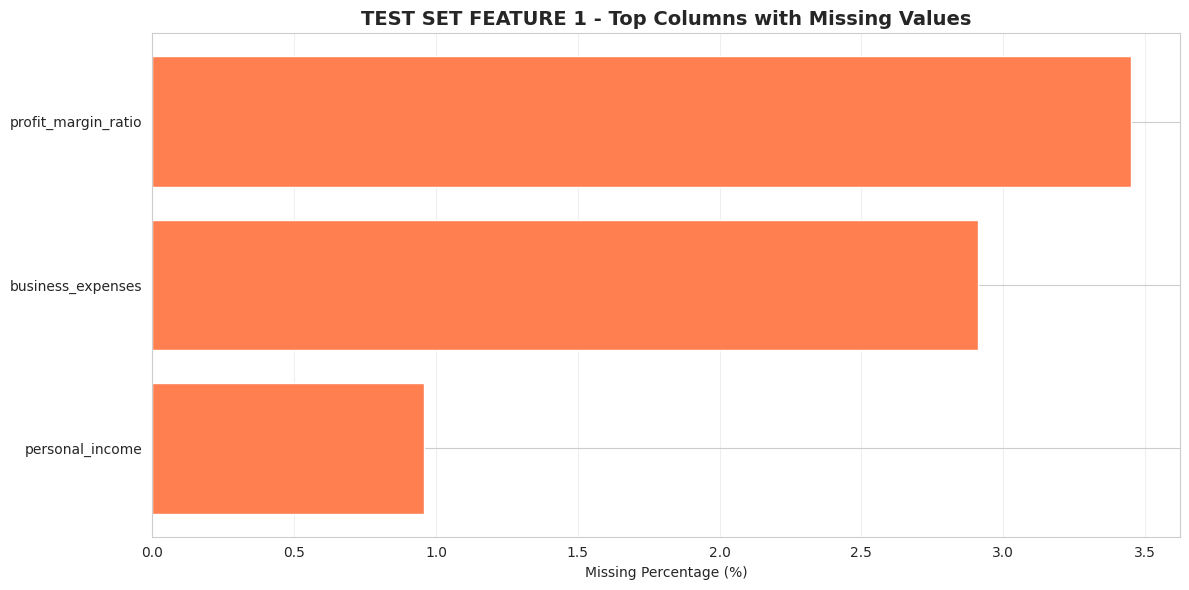

,Column,Missing_Count,Percentage
2,profit_margin_ratio,83,3.451143
1,business_expenses,70,2.910603
0,personal_income,23,0.956341


In [ ]:
analyze_missing(test_df[categories_feature_1], "TEST SET FEATURE 1")

#### Summary

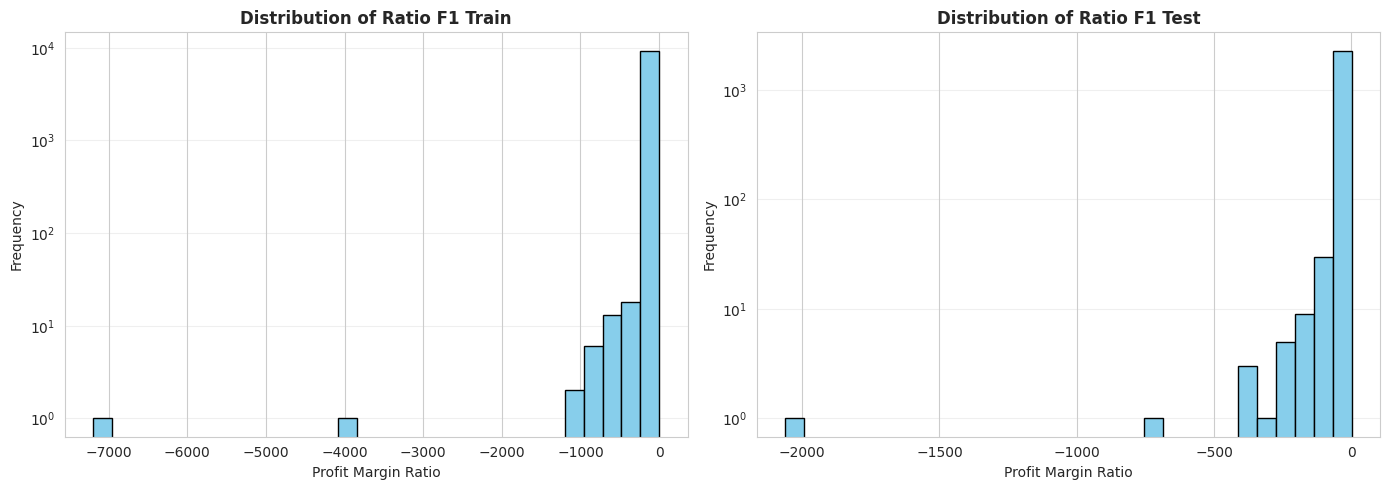

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes = axes.ravel()
train_df['profit_margin_ratio'].hist(bins=30, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title(f'Distribution of {'Ratio F1 Train'}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Profit Margin Ratio')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

test_df['profit_margin_ratio'].hist(bins=30, ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title(f'Distribution of {'Ratio F1 Test'}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Profit Margin Ratio')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.3)

axes[0].set_yscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

Guided by the Zindi.Africa notebook, I created a ````profit_margin_ratio```` feature for both the train and test datasets. I visualized the frequency count in the graphs above. They were similar to the graphics produced in the [Numeric Feature Analysis section](#scrollTo=Numerical_Feature_Analysis), so I added a line of code that I have tested there but I removed it from that section. I converted the graphics into a log scale. This way, I can more clearly see the pattern defined by the new variable or feature.

The starter notebook also guided me to produce a cross tabulation of the FHI Target variable, and the new profit margin ratio. That cross tabulation was produced below. Ofcourse, the target variable is only in the training data set and not in the testing data set. Here I am replicating steps from the [Exploring Key Features section](#scrollTo=Explopring_Key_Features). From there, I could only reliably say that I see most profit margin values occur in the low code/label, which is similar to *personal_income*, and *business_expenses* before. On average, the ratio is lowest for the *high* target variable label/code, and highest for the *medium* target variable code. The *medium* code also has the lowest deviation from the mean of the *profit margin ratio*, while the *high* code has the highest deviation from the mean for the feature under consideration.

In [ ]:
# ========================================
# FEATURE 1 RELATIONSHIP WITH TARGET
# ========================================

if 'Target' in train_df.columns:
    print("\nProfit Margin Ratio by Target:")
    grouped_stats = train_df.groupby('Target')['profit_margin_ratio'].agg(['mean', 'median', 'std', 'count'])
    print(grouped_stats)


Profit Margin Ratio by Target:
             mean    median         std  count
Target                                        
High   -16.164078 -0.500000  187.216634    461
Low    -10.370811 -0.250000  103.589236   6101
Medium  -7.128733 -0.333333   32.573890   2776


Finally, there is variation in profit margins between the FHI codes. The variation is a negative relation on average, and defined by the median values. It can serve as a strong predictor in models, as a relation was discovered, although it is negative.


### Financial Access Score


Next, we are going to create the financial access score. This feature is a bit more complex because no mathematical formula was given. Rather, it was left as a task for the competition participant to complete. The idea behind this feature is to create a variable that is going to measure access to formal financial services.

In creating this feature, one is expect to consider the following existing features:
* Bank accounts,
* loans,
* internet banking,
* debit cards,
* and, insurance.

*Financial Access Score*, henceforth refered to as FAS, is calculated by following the following rules:
* FAS is directly and positively related a positive response in any financial service usage (factor to be determined by engineer),
*  - Partial credit for past usage  -- need clarity on this
* FAS is a normalized value that lies between 0 and 1, where 0 represents no access and 1 represents full access.  

The FAS score reflects financial inclusion and sophistication. It should help our model to identify businesses that leverage formal financial tools and it has a positive correlation with financial health.

In [ ]:
# ----------------------------------------
# Feature 2: Financial Access Score
# ----------------------------------------
def create_financial_access_score(df : pd.DataFrame):
    """
    Calculate a composite score of financial service access.
    Higher score = better access to formal financial services.
    """
    financial_features = [
        'has_bank_account', 'has_loan_account', 'has_internet_banking',
        'has_debit_card', 'medical_insurance', 'funeral_insurance'
    ]

    # Available features in the dataset
    available_features = [col for col in financial_features if col in df.columns]

    scores = []
    for idx, row in df.iterrows():
        score = 0
        valid_features = 0

        for feature in available_features:
            value = row.get(feature, np.nan)

            if pd.notna(value):
                valid_features += 1
                # Check for positive responses
                if value in ['Yes', 'Have now', 'have now']:
                    score += 1
                elif value in ['Used to have but don\'t have now', 'used to have']:
                    score += 0.5  # Partial credit for past access

        # Normalize by number of valid features checked
        if valid_features > 0:
            normalized_score = score / valid_features
        else:
            normalized_score = np.nan

        scores.append(normalized_score)

    return scores

Fortunately, I found the relevant code section in the starter file to almost automatically complete this section, where I completely designed the first feature myself. Above is the FAS computation algorithm.

In [ ]:
train_df['financial_access_score'] = create_financial_access_score(train_df)
test_df['financial_access_score'] = create_financial_access_score(test_df)

print(f"\n✓ Created 'financial_access_score' feature")


✓ Created 'financial_access_score' feature


In [ ]:
print(f"  Train - Non-null values: {train_df['financial_access_score'].notna().sum()}")
print(f"  Test - Non-null values: {test_df['financial_access_score'].notna().sum()}")

  Train - Non-null values: 8228
  Test - Non-null values: 2066


In [ ]:
print("\nSample statistics:")
train_df['financial_access_score'].describe()


Sample statistics:


,financial_access_score
count,8228.000000
mean,0.193806
std,0.276890
min,0.000000
25%,0.000000
50%,0.000000
75%,0.333333
max,1.000000



FAS by Target:
            mean    median       std
Target                              
High    0.499569  0.450000  0.246445
Low     0.094173  0.000000  0.208572
Medium  0.379353  0.333333  0.290280


<Figure size 1000x500 with 0 Axes>

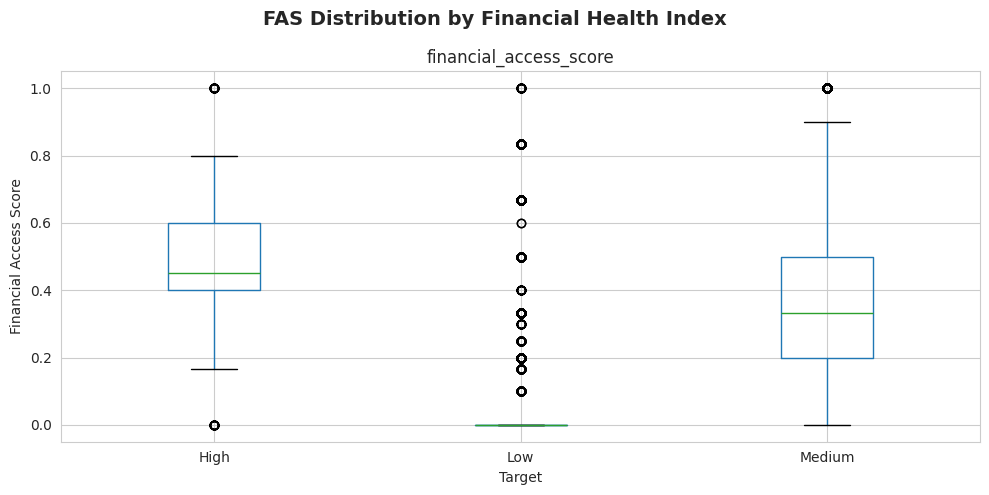

In [ ]:

# Show relationship with target
if 'Target' in train_df.columns:
    print("\nFAS by Target:")
    print(train_df.groupby('Target')['financial_access_score'].agg(['mean', 'median', 'std']))

    # Visualize
    plt.figure(figsize=(10, 5))
    train_df.boxplot(column='financial_access_score', by='Target', figsize=(10, 5))
    plt.suptitle('FAS Distribution by Financial Health Index',
                 fontsize=14, fontweight='bold')
    plt.xlabel('Target')
    plt.ylabel('Financial Access Score')
    plt.tight_layout()
    plt.show()

So, wholly guided by the notebook, I have developed the FAS indicator. A box plot was generated to visualize FAS continuous values or normalized values by `Target` labels, to help us to identify trends. There is no immediate trend that I can discern from the box plot.



## FEC Summary

At the end of this [Feature Engineering section](#scrollTo=Feature_Engineering) I should have developed **two (2) new features**:
* **profit_margin_ratio** to measure business profitability  
* and, **financial_access_score** to measure access to formal financial services  

The starter notebook suggested the following additional features:
* Age bins (categorize ````owner_age````)  
* Income-to-expenses ratio  
* Business maturity (young vs. established)  
* Risk perception score (combine attitude variables)  
* Country-specific patterns  
* Insurance coverage index  
* Digital banking adoption flag

But I might not have the time to develop the ideas and mathematics behind them, and to implement the results of those calculations into my data sets.

# Modelling

## Preparations


As guided by the notebook, and the "*Prepare the Data for Machine Learning*" section in Geron's project example, before training a model, we need to "separate the predictors from the labels since we don't necessarily want to apply the same transformations to the predictors and the target values".

For our own notes, we will use the following as a reminder about our training data:
* X_train: features for training or ````train_df```` without ````Target```` and ````ID````
* Y_train: target FHI variable

For the test data, we will make the following reminder:
* X_test: features for prediction or ````test_df```` without ````ID````

In [ ]:
X_train = train_df.drop(columns=['Target', 'ID'])
Y_train = train_df['Target']

X_test = test_df.drop(columns=['ID'])

In [ ]:
print(f"\nX Train Dataset (without Target and ID) Shape: {X_train.shape}")
print(f"\nY Train Dataset (with Target) Shape: {Y_train.shape}")
print(f"Test Dataset Shape: {X_test.shape}")


X Train Dataset (without Target and ID) Shape: (9618, 39)

Y Train Dataset (with Target) Shape: (9618,)
Test Dataset Shape: (2405, 39)


### Handling Text and Categorical Attributes

According to the starter notebook and Geron, most machine learning algorithms prefer to work with numbers and not categorical variables. Thus, this step is designed to help us to convert all categorical columns (prior identified as ````objects```` rather than the ````int```` and ````float```` data types of the numeric features). We will do this for features in ````X```` and those in ````X_test````. The function defined for us is ````change_object_to_cat````. Again, I felt little guilt in using it as is for this assignment, it is written out in the code section below for easy execution in our notebook.

In [ ]:
def change_object_to_cat(input_df: pd.DataFrame) -> (pd.DataFrame, list[str]):
  # return columns that are object type
  list_str_obj_cols = input_df.select_dtypes(include=['object']).columns.tolist()

  # enumerate column list and convert column dataType to category
  for str_obj_col in list_str_obj_cols:
      input_df[str_obj_col] = input_df[str_obj_col].astype("category")

  return input_df,list_str_obj_cols

# Code left her for some kind of awareness.

The step above is a preparatory step, for now we expect nothing except that our *object* type columns were converted to *category* type columns. Geron uses an ordinal encoder function/s; ````OrdinalEncoder```` and ````OneHotEncoder````. These are more useful because they make the conversion that we actually need from *object* or *categorical* data to *multiple binary* data columns per label/code/class. So, in actual fact, after running my regression model and having it cough up my data because it cannot work with objects or categories, I decided to implement Geron's technique from the example project below.

I ran Geron's technique with both the ````OrdinalEncoder```` and the ````OneHotEncoder````. I found that I did not need to execute code with the former of the two, and I could skip directly to what I would actually need, and that is the latter encoder.

In [ ]:
def change_object_to_binary_classes(input_df: pd.DataFrame) -> (pd.DataFrame, list[str]):
  # We call in our encoder functions
  # ordinal_encoder = OrdinalEncoder() # ordinal encoder is not needed as we need to blow up our categorical variables into binary variables by labels/codes/classes
  onehot_encoder = OneHotEncoder()

  # next we return all the columns that are of object type/categorical columns
  list_str_obj_cols = input_df.select_dtypes(include=['object']).columns.tolist()

  # enumerate column list and convert column dataType to category
  for df_col in list_str_obj_cols:
    generic_cat = pd.DataFrame(input_df[df_col])
    generic_cat_1hot_encoded = onehot_encoder.fit_transform(generic_cat).toarray()
    new_col_headings = [f'{df_col}_{str(cat_name).replace("\\", "").replace("\'", "").replace(" ","_")}' for cat_name in onehot_encoder.categories_[0]]
    new_columns = pd.DataFrame(data=generic_cat_1hot_encoded, columns=new_col_headings)
    input_df = input_df.drop(columns=[f'{df_col}'])
    #input_df = pd.concat(input_df, new_columns, axis=1)
    input_df = input_df.join(new_columns)
    pass

  return input_df,list_str_obj_cols

X_train, train_cat_list = change_object_to_binary_classes(X_train)
#display(X_train)
#display(cat_list)
X_test, test_cat_list = change_object_to_binary_classes(X_test)

In [ ]:
print(f"\nX Train Dataset Shape: {X_train.shape}")
print(f"\nTrain Cat List Shape: {train_cat_list}")
print(f"\nY Train Dataset Shape: {Y_train.shape}")
print(f"X Test Dataset Shape: {X_test.shape}")
print(f"\nTest Cat List Shape: {test_cat_list}")


X Train Dataset Shape: (9618, 136)

Train Cat List Shape: ['country', 'attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax', 'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 'motor_vehicle_insurance', 'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'offers_credit_to_customers', 'attitude_satisfied_with_achievement', 'has_credit_card', 'keeps_financial_records', 'perception_insurance_companies_dont_insure_businesses_like_yours', 'perception_insurance_important', 'has_insurance', 'covid_essential_service', 'attitude_more_successful_next_year', 'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account', 'has_internet_banking', 'has_debit_card', 'future_risk_theft_stock', 'medical_insurance', 'funeral_insurance', 'motivation_make_more_money', 'uses_friends_family_savings', 'uses_informal_lender']

Y Train Dataset Shape: (9618,)
X Test Dataset Shape: (2405, 132)

Test Cat Lis

### Handling Train and Validation Dataset Split

In order to train our model, we will split the training dataset that we already have into two (2). The first part of it will be the data set we will use for *training*, and the second part of it will be the dataset that we will use for *validation*. The latter of the two is not to be confused with the *testing* data set.

For our notes, splitting will be dones as follows:
* Training Set: ````(X_train_split, Y_train_split)```` -- 80% of current training data
* Validation Set: ````(X_val, Y_val)```` -- 20% of current training data


In [ ]:
X_train_split, X_val, Y_train_split, Y_val = train_test_split(
    X_train, Y_train, test_size=0.2, random_state=42, stratify=train_df[['country', 'Target']]
)

There are bits explained in the starter notebook that I must also devle into. ````random_state=42```` is supposed to ensure reproducibility. ```stratify=train_df[['country','Target']]```` is supposed to help us to preserve the original distribution across both dimensions, and ensures a balanced representation in both training and validation data sets. After the code section above is executed, we should have a reliable evaluation set, that maintains class and country distribution (reducing bias). This step actually reveals that the test data set that I have been working with up until now must have been derived in this way because it showed similar patterns of relations as the training data set, prior to the split.

In [ ]:
Y_train_split.describe()

,Target
count,7694
unique,3
top,Low
freq,5024


In [ ]:
Y_train_split.head()

,Target
5111,Medium
3681,Medium
5087,High
2608,Medium
7554,Low


In [ ]:
print(f"\nX Train Split Dataset Shape: {X_train_split.shape}")
print(f"\nX Validation Shape: {X_val.shape}")
print(f"\nY Train Split Dataset Shape: {Y_train_split.shape}")
print(f"Y Validation Shape: {Y_val.shape}")


X Train Split Dataset Shape: (7694, 136)

X Validation Shape: (1924, 136)

Y Train Split Dataset Shape: (7694,)
Y Validation Shape: (1924,)


## Model Training

Believe it or not, after all of that, now we are ready to begin on the very first question of our assignment, picking a model and training it on our dataset. My options are between two *supervised learning* algorithms:
* **Decision Tree:** a decision tree is an algorithm that is used for both classification and regression tasks. It produces a structure like a tree data structure. It works like a flowchart in that it makes decisions step-by-step by asking a chain of sequential "Yes/No" questions. It splits the data using perpendicular, step-like boundaries based on distinct thresholds. The Leaf nodes of the final tree represent final decisions or predictions.
* **Logistic Regression:** is an algorithm that is commonly used for classification problems: unlike *linear regression*, which predicts a continuous independent variables. *Logistic regression* predicts the probability that an input belongs to a specific class by assuming that features have a linear relationship with the log-odds of the target variable. It then tries to draw a single, straight boundary line that cleanly separates the variable codes/labels/classes.


Then, I am expected to implement and compare two ensemble methods on the model. These are:
* Bagging (e.g. Random Forest)
* Boosting (XGBoost/Extreme Gradient Boosting)

The starter notebook from Zindi.Africa unfortunately traings their model with *LightGBM classifier* to predict the target *FHI* variable and to evaluate its performance. **LightGBM** stands for *Light Gradient Boosting Machine*, it is an incredibly fast, high-performance, open-source framework developed by Microsoft. According to GeeksforGeeks, LightGBM is an ensemble learning framework, "it uses the gradient boosting method which constructs a strong learner by sequentially adding weak learners in a gradient descent manner".

The steps followed in the starter notebook follow:
1. Initialize and Train Model
2. Make Predictions
3. Evaluate the Model
4. Feature Importance

After doing some research, I am going to choose the **decision tree** because "*decision trees do not care if you have 2, 3, or 50 classes. When a tree looks at a node, it simply evaluates which feature split cleanest separates the data into the target \[classes\]*".

#### Initialize and Train the Model

In [ ]:
# -------------------------
# Train Decision Tree
# -------------------------
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train_split, Y_train_split)



DecisionTreeClassifier(max_depth=5)

The command above states "FITTED" in the information window. For now, I do not get to see any kind of cool stuff but as I have done all along in this assignment, I only get to believe! I am kidding, I have print assignments everywhere, display functions -- I like to see things happen. Unfortunately, this code is from half way across the internet and also deep parts of the text authored by Geron. Below, I made an attempt to produce a graphical image from the model that I trained -- having executed the code as printed out on chapter 6 of the guidebook, I discovered in the lines below the code that the ````.dot```` file I produced needs a special kind of CLI program to read it. Though I did import the ````os```` package/module against my better judgement, as now my script is a walking vulnerability on my Google Drive storage, and I believe that it can be used by me to run BASH commands from Jupyter notebook... I am not going to do so.

In [ ]:
def image_path(file_name: str) -> str:
  final_destination = os.path.join(file_path, file_name)
  return final_destination

export_graphviz(
        model,
        out_file=image_path("SADC_FHI_tree.dot"),
        feature_names=X_train_split.columns.to_list()[:],
        class_names=Y_train_split.value_counts().index.to_list(),
        rounded=True,
        filled=True
)

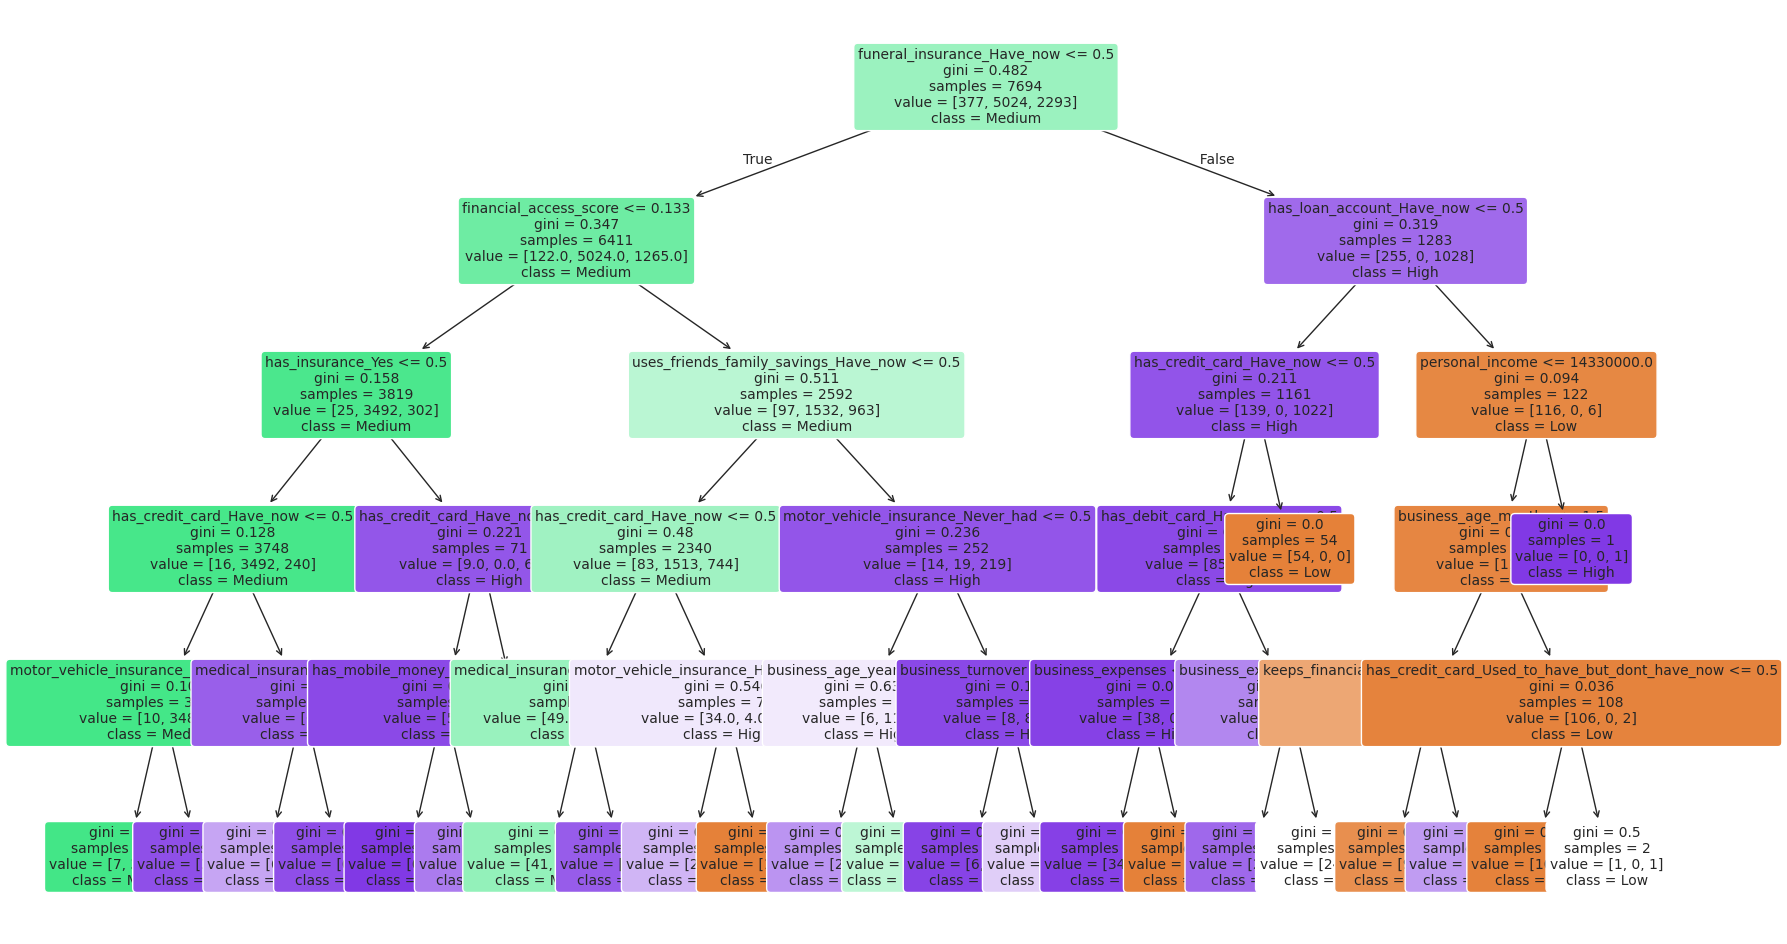

In [ ]:
plt.figure(figsize=(20, 12))

# 2. Run the plot function
plot_tree(
    model,
    feature_names=X_train_split.columns.tolist(),
    class_names=[
        str(c) for c in Y_train_split.value_counts().index.tolist()
    ],  # Ensuring string format for scikit-learn
    filled=True,  # Color-codes the nodes based on major classes
    rounded=True,  # Rounds the edges of the decision boxes
    fontsize=10,  # Tweaks text size so it fits inside nodes smoothly
)

# 3. Cleanly render inside Jupyter
plt.show()

I switched my efforts towards using something that will give me immediate results. The results came too quickly because as defined earlier, for DecisionTreeClassifiers the leaf nodes are the solutions. I can only read the right-most node on this tree. Thus, I cannot fully appreciate the work that has been done. Infact, the tree is too large (does not fit adequately to the screen) to be able to use directly for making predictions as directed by Geron.

## Make Predictions

In [ ]:
# -------------------------
# Predictions
# -------------------------
Y_pred = model.predict(X_val)

Y_pred_prob = model.predict_proba(X_val)

Geron states that because a *Decision Tree* is a white box model, it is intuitive and how it works is somewhat opaque. If only we could produce the complete tree for my model! Since we cannot produce the tree, we can still use functions to give us estimates. Having the tree is only to say that we could have cross-referenced, graphically, how to reach the answer. He explains this in the *Chapter 6* sections "*Making Predictions*" and "*Estimating Class Probabilities*". Above, I have used both the *predict class probabilities* function (bottom function) and the normal *prediction* function (top) packaged in regression models. As the function was available in the ````DecisionTreeClassifier```` I can only assume it is a valid operation.

In [ ]:
display(Y_pred)

array(['Low', 'Low', 'Low', ..., 'Low', 'Low', 'Low'], dtype=object)

In [ ]:
display(Y_pred_prob)

array([[0.00191257, 0.95300546, 0.04508197],
       [0.01855204, 0.68280543, 0.29864253],
       [0.00191257, 0.95300546, 0.04508197],
       ...,
       [0.01855204, 0.68280543, 0.29864253],
       [0.01855204, 0.68280543, 0.29864253],
       [0.00191257, 0.95300546, 0.04508197]])

In [ ]:
percentages_np = (Y_pred_prob/Y_pred_prob.sum())*100
p_np_series = pd.DataFrame(data=percentages_np)
display(p_np_series.style.format('{:.2f}%'))

,0,1,2
0,0.00%,0.05%,0.00%
1,0.00%,0.04%,0.02%
2,0.00%,0.05%,0.00%
3,0.03%,0.00%,0.03%
4,0.00%,0.05%,0.00%
5,0.00%,0.05%,0.00%
6,0.00%,0.04%,0.02%
7,0.00%,0.05%,0.00%
8,0.00%,0.00%,0.05%
9,0.00%,0.04%,0.02%


I could only browse the resultant table above. It is interesting, the probabilities are rather miniscule. The result is underwhelming, but I will give myself more time to look at it.

## Model Evaluation

In [ ]:
# -------------------------
# Evaluation:
# -------------------------
print("Classification Report:")
print(classification_report(Y_val, Y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_val, Y_pred))


Classification Report:
              precision    recall  f1-score   support

        High       0.93      0.60      0.73        93
         Low       0.85      0.99      0.92      1256
      Medium       0.91      0.63      0.74       575

    accuracy                           0.86      1924
   macro avg       0.90      0.74      0.80      1924
weighted avg       0.87      0.86      0.86      1924


Confusion Matrix:
[[  56    9   28]
 [   0 1248    8]
 [   4  211  360]]


In [ ]:
# -------------------------
# Evaluation: Probabilities
# -------------------------
""" FAILED
print("Classification Report:")
print(classification_report(Y_val, Y_pred_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_val, Y_pred_prob))
"""

' FAILED\nprint("Classification Report:")\nprint(classification_report(Y_val, Y_pred_prob))\n\nprint("\nConfusion Matrix:")\nprint(confusion_matrix(Y_val, Y_pred_prob))\n'

In the code above, I produce a **classification report**, which shows precision, recall, and F1-score for each class. I have also produced a **confusion matrix** that visualizes true vs predicted labels. I performed these steps for the regular predications, above, and probablity predictions, below. I am intrigued by the probabilities in this kind of scenario as well as the raw numbers. However, the probabilities failed with the note that "*Classification metrics can't handle a mix of multiclass and continuous-multioutput targets*" or more specifically "*Classification metrics can't handle a mix of {0} and {1} targets*". The classification report produces 4 metrics against each of the classes of the target variable, in the top part of the classification table. These are;
* **Precision:** this is the ratio between True Positives and all the Positives. It shows how many of the “yes” predictions made by the model were actually correct. It is designed to help us reduce wrong “yes” guesses which are called false positives (FP).
* **Recall:** recall tells us how well a model finds all the correct “yes” cases in the data. It checks how many real positive cases the model was able to correctly identify.
* **F1-Score:** F1 Score is a metric used to evaluate the performance of a classification model. It combines precision and recall into a single value and is especially useful when the dataset has imbalanced classes.
* **Support:**

The descriptions above and below were taken from GeeksforGeeks and I have included them in my report to help me in making my analysis.

The **confusion matrix** produced below is said to be a table used to evaluate the performance of a classification model. It compares the actual labels with the predicted labels to show how many predictions were correct or incorrect.


In [ ]:
# -------------------------
# Extract top 50 most important features
# -------------------------
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

top50 = feature_importances.sort_values("importance", ascending=False).head(50)
print("\nTop 50 Features:")
print(top50)


Top 50 Features:
                                               feature  importance
119                         funeral_insurance_Have_now    0.502910
7                               financial_access_score    0.137219
62                            has_credit_card_Have_now    0.101014
96                           has_loan_account_Have_now    0.070953
127               uses_friends_family_savings_Have_now    0.066719
79                                   has_insurance_Yes    0.049855
34                    motor_vehicle_insurance_Have_now    0.026234
114                         medical_insurance_Have_now    0.018944
106                            has_debit_card_Have_now    0.007664
2                                    business_expenses    0.006436
35                   motor_vehicle_insurance_Never_had    0.004682
3                                    business_turnover    0.001703
4                                   business_age_years    0.001272
117                              medical_ins

## Test Data Predictions

In [ ]:
# -------------------------
# Predictions
# -------------------------
predictions_final = model.predict(X_test)

predictions_prob_final = model.predict_proba(X_test)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- funeral_insurance_Dont_know_(Do_not_show)
Feature names seen at fit time, yet now missing:
- attitude_stable_business_environment_nan
- attitude_worried_shutdown_nan
- compliance_income_tax_nan
- funeral_insurance_Dont_know
- uses_informal_lender_Dont_know_(Do_not_show)


To get this far, I had to blow up my feature set from about 39 features to close to 300 features. This was dues to each categorical variable being exploded by a factor of the number of codes. It probably helped that I spent the time to merge the codes/labels/classes. This section has not been completed.

## Zindi.Africa Submission

In [ ]:
final_pred_df = pd.DataFrame({
    "ID": test_df["ID"].values,
    "Target": predictions_final
})


final_pred_df.to_csv('submission.csv', index=False)

final_pred_df

# Assignment Write Up

# References

* Bengio, Y., Hinton, G., LeCun, Y.. Deep learning. Nature. 2015. Web.
* GeeksforGeeks. MNIST Dataset : Practical Applications Using Keras and PyTorch. GeeksforGeeks, 7 Feb 2026. Web. 24 May 2026.
* Numpy Community. Deep learning on MNIST. Numpy.org, n.d. Web. 24 May 2026.
* Scikit Learn. Ensembles: Gradient boosting, random forests, bagging, voting, stacking. SciKit Learn Developers (BSD License), 2026. Web. 20 April 2026.
* Verma, J.. MNIST Dataset in Python: Complete Guide with Examples. Digital Ocean, 4 Aug 2022. Web. 24 May 2026.

* Geron, A.. Hands-On Machine Learning with Scikit-Learn, Kera, and TensorFlow. Boston: O'Reilly, 2019. Ebook.
* Huawei AI Academy Training Material: Deep Learning. Shenzen: HiSilicon (Shanghai)Technologies Co., Ltd., 2020. Ebook.
* Gonzalez, J., Nolan, D., Lau, S.. Learning Data Science: Data Wrangling, Exploration, Visualization, and Modeling with Python. Sebastopol: O'Reilly Media, Inc., 2023. Ebook.
* Bengio, Y., Courville, A., Goodfellow, I.. Deep Learning. Cambridge: MIT Press, 2016. Ebook.

